# Data Preprocessing  —  3-Class Setup
Melanoma · Nevus · Basal Cell Carcinoma

**Training datasets:** HIBA (paired) + Derm7pt (paired)  
**Cross-evaluation datasets:** Fitzpatrick17k · PAD-UFES-20 · ISIC2019

## Phase 0 — Environment Setup

In [116]:
!pip install -q scikit-learn matplotlib seaborn pandas tqdm Pillow scikit-image



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [117]:
import os, re, glob, random, math, json, warnings, shutil
from pathlib import Path
from collections import defaultdict
from concurrent.futures import ThreadPoolExecutor

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from PIL import Image
from tqdm import tqdm
from sklearn.model_selection import train_test_split

warnings.filterwarnings('ignore')
SEED = 42
random.seed(SEED); np.random.seed(SEED)
print('Imports ready.')


Imports ready.


## Phase 1 — Configuration & Label Taxonomy

In [118]:
# ════════════════════════════════════════════════════════════════════════════
# GLOBAL CONFIG
# ════════════════════════════════════════════════════════════════════════════
# Update DRIVE_ROOT and WORK_ROOT to match your environment.
DRIVE_ROOT = Path('C:\\Users\\asose\\OneDrive\\Desktop\\SengeResearch\\datasets')
WORK_ROOT  = Path('process\\process\\outputs')

CFG = dict(
    hiba_root     = DRIVE_ROOT / 'HIBASkinLesionsDataset-main',
    derm7pt_root  = DRIVE_ROOT / 'Derm7pt',

    # Cross-evaluation datasets (unpaired)
    fitz_root     = DRIVE_ROOT / 'fitzpatrick17k',
    padufes20_root= DRIVE_ROOT / 'PAD-UFES-20',
    isic2019_dir  = DRIVE_ROOT / 'ISIC2019',

    # Outputs
    csv_dir  = WORK_ROOT / 'csvs',
    eda_dir  = WORK_ROOT / 'eda',

    num_classes    = 2,   # melanoma / nevus / basal cell carcinoma
    num_skin_types = 6,
)

# 3-class label space
LABEL_NAMES = {
    0: 'benign',
    1: 'malignant',
}

FST_NAMES = {i: f'FST {i+1}' for i in range(6)}
_PAL_CLS  = ['#1950A0', '#DC641E']   # one colour per class
_PAL_FST  = ['#FFEDE0', '#F4C18C', '#D49060', '#A0522D', '#5C3317', '#2B1500']

for k in ['csv_dir', 'eda_dir']:
    CFG[k].mkdir(parents=True, exist_ok=True)

print('Config ready. Checking dataset roots:')
for k in ['hiba_root','derm7pt_root','fitz_root','padufes20_root','isic2019_dir']:
    status = 'OK' if CFG[k].exists() else 'MISSING — update path'
    print(f'  [{status}]  {k}')


Config ready. Checking dataset roots:
  [OK]  hiba_root
  [OK]  derm7pt_root
  [OK]  fitz_root
  [OK]  padufes20_root
  [OK]  isic2019_dir


In [119]:
# ════════════════════════════════════════════════════════════════════════════
# LABEL TAXONOMY & SHARED HELPERS
# ════════════════════════════════════════════════════════════════════════════

VALID_LABELS = {0, 1}

def _clean(s: str) -> str:
    s = str(s).lower().strip()
    s = re.sub(r'[-_]+', ' ', s)
    s = re.sub(r'\s+', ' ', s)
    return s

# ── HIBA (benign_malignant column) ───────────────────────────────────────────────
HIBA_MAP = {
    'benign':            0,
    'malignant':         1,
}

# ── Derm7pt (meta.csv 'diagnosis' column) ────────────────────────────────
DERM7PT_MAP = {
    'dermal nevus':                 0,
    'clark nevus':                  0,
    'reed or spitz nevus':          0,
    'blue nevus':                   0,
    'recurrent nevus':              0,
    'combined nevus':               0,
    'congenital nevus':             0,
    'dermatofibroma':               0,
    'lentigo':                      0,
    'vascular lesion':              0,
    'melanosis':                    0,
    'miscellaneous':                0,
    'seborrheic keratosis':         0,
    'basal cell carcinoma':         1,
    'melanoma':                     1,
    'melanoma (in situ)':           1,
    'melanoma (less than 0.76 mm)': 1,
    'melanoma (0.76 to 1.5 mm)':    1,
    'melanoma (more than 1.5 mm)':  1,
    'melanoma metastasis':          1,
}

# ── Fitzpatrick17k ('three_partition_label' column) ───────────────────────────────────────────
FITZ_MAP_2CLS = {
    'benign': 0, 
    'malignant': 1,
}

# ── PAD-UFES-20 (cross-eval 'diagnostic' column) ──────────────────────────────────────────────
PADUFES_MAP_2CLS = {
    'nev': 0,   # nevus
    'ack': 0,   # actinic keratosis
    'sek': 0,   # seborrheic keratosis
    'mel': 1,   # melanoma
    'bcc': 1,   # basal cell carcinoma
    'scc': 1,   # squamous cell carcinoma
}

# ── ISIC2019 (cross-eval, one-hot columns) ────────────────────────────────
ISIC2019_COL_MAP_2CLS = {
    'NEV':  0,
    'AK':   0,
    'BKL':  0,
    'DF':   0,
    'VASC': 0,
    'UNK':  0,
    'MEL':  1,
    'BCC':  1,
    'SCC':  1,
}


def harmonize_label(raw: str, mapping: dict) -> 'int | None':
    s = _clean(raw)
    if s in mapping:
        v = mapping[s]
        return v if v in VALID_LABELS else None
    for k, v in mapping.items():
        if k in s or s in k:
            return v if v in VALID_LABELS else None
    if 'nevus' in s or 'nevi' in s:
        return 1
    return None

def parse_fst(raw) -> int:
    try:
        v = int(float(str(raw).strip()))
        return v - 1 if 1 <= v <= 6 else -1
    except (ValueError, TypeError):
        return -1

_ROMAN = {'i':1,'ii':2,'iii':3,'iv':4,'v':5,'vi':6}
def parse_fst_roman(raw) -> int:
    s = str(raw).lower().strip()
    if s in _ROMAN:
        return _ROMAN[s] - 1
    return parse_fst(raw)

def _verify_labels(df, name):
    if df.empty: return df
    before = len(df)
    df = df[df['label'].between(0, CFG['num_classes']-1)].copy()
    if before - len(df):
        print(f'  [WARN] {name}: dropped {before-len(df)} out-of-range rows')
    vc = df['label'].value_counts().sort_index()
    print(f'  {name}: {len(df)} rows | ' +
          '  '.join(f'{LABEL_NAMES.get(k,"?")}={v}' for k, v in vc.items()))
    return df

def _build_image_map(root_dir: Path, exts=['.jpg','.jpeg','.png']):
    m = {}
    for ext in exts:
        for p in root_dir.rglob(f'*{ext}'):
            m[p.stem] = p
            m[p.name] = p
    return m

def _safe_split_3way(df, val_size=0.1, test_size=0.2, seed=SEED):
    if df.empty:
        return df, df.iloc[:0], df.iloc[:0]
    cts  = df['label'].value_counts()
    rare = cts[cts < 2].index
    df_rare = df[df['label'].isin(rare)]
    df_rest = df[~df['label'].isin(rare)]
    if df_rest.empty:
        return df, df.iloc[:0], df.iloc[:0]
    try:
        df_tv, df_test = train_test_split(df_rest, test_size=test_size,
                                          random_state=seed, stratify=df_rest['label'])
    except ValueError:
        df_tv, df_test = train_test_split(df_rest, test_size=test_size, random_state=seed)
    rel_val = val_size / (1.0 - test_size)
    try:
        df_train, df_val = train_test_split(df_tv, test_size=rel_val,
                                            random_state=seed, stratify=df_tv['label'])
    except ValueError:
        df_train, df_val = train_test_split(df_tv, test_size=rel_val, random_state=seed)
    df_train = pd.concat([df_train, df_rare], ignore_index=True)
    return df_train, df_val, df_test

print('Label taxonomy & helpers ready — 2 classes: benign / malignant.')


Label taxonomy & helpers ready — 2 classes: benign / malignant.


In [120]:
# ════════════════════════════════════════════════════════════════════════════
# ITA-BASED FST ESTIMATOR  (for Derm7pt clinical images)
# ════════════════════════════════════════════════════════════════════════════

_ITA_BRACKETS = [
    ( 55.0,  float('inf'), 0),
    ( 28.0,  55.0,         1),
    ( 10.0,  28.0,         2),
    (-30.0,  10.0,         3),
    (-55.0, -30.0,         4),
    (float('-inf'), -55.0, 5),
]

def _ita_to_fst(ita: float) -> int:
    for lo, hi, fst in _ITA_BRACKETS:
        if lo < ita <= hi:
            return fst
    return _ITA_BRACKETS[-1][2]

def _estimate_fst_single(path: str, min_skin_frac: float = 0.05, thumb_size: int = 96) -> int:
    try:
        from skimage import color as _skc
        img = Image.open(path).convert('RGB').resize((thumb_size, thumb_size), Image.BILINEAR)
        rgb = np.asarray(img, dtype=np.float32) / 255.0
        lab = _skc.rgb2lab(rgb)
        L, a, b = lab[...,0], lab[...,1], lab[...,2]
        mask = (L > 20) & (L < 90) & (a > 2) & (b > 5)
        if mask.mean() < min_skin_frac:
            return -1
        mL = float(L[mask].mean()); mb = float(b[mask].mean())
        if abs(mb) < 1e-6: return -1
        return _ita_to_fst(float(np.degrees(np.arctan((mL - 50.0) / mb))))
    except Exception:
        return -1

def estimate_fst_for_df(df: pd.DataFrame, path_col: str,
                        n_jobs: int = 4, cache_csv: Path = None) -> pd.DataFrame:
    """Estimate FST via ITA for every row. Saves/loads a cache CSV."""
    if cache_csv is not None and Path(cache_csv).exists():
        cached = pd.read_csv(cache_csv)
        if 'skin_type' in cached.columns and len(cached) == len(df):
            df = df.copy()
            df['skin_type'] = cached['skin_type'].values
            n = int((df['skin_type'] >= 0).sum())
            print(f'  [FST cache] loaded {n}/{len(df)} from {Path(cache_csv).name}')
            return df
    print(f'  Estimating FST via ITA for {len(df)} images (n_jobs={n_jobs}) …')
    paths = df[path_col].tolist()
    with ThreadPoolExecutor(max_workers=n_jobs) as ex:
        fst_vals = list(tqdm(ex.map(_estimate_fst_single, paths),
                             total=len(paths), desc='  ITA-FST', leave=True))
    df = df.copy()
    df['skin_type'] = fst_vals
    n = sum(v >= 0 for v in fst_vals)
    print(f'  FST estimated: {n}/{len(df)} ({100*n/max(len(df),1):.1f}%)')
    for fi in range(6):
        cnt = sum(v == fi for v in fst_vals)
        if cnt: print(f'    FST {fi+1}: {cnt:>5}')
    if cache_csv is not None:
        df.to_csv(cache_csv, index=False)
        print(f'  Saved FST cache → {Path(cache_csv).name}')
    return df

print('ITA-FST estimator ready.')


ITA-FST estimator ready.


## Phase 2 — Dataset Parsers
### 2-A  Training Datasets (Paired)

In [121]:
# ════════════════════════════════════════════════════════════════════════════
# HIBA PARSER — 2-class (benign / malignant)
# ════════════════════════════════════════════════════════════════════════════

def parse_hiba_2cls(root: Path):
    candidates = (list(root.rglob('metadata.csv')) +
                  list(root.rglob('hiba_metadata.csv')) +
                  list(root.rglob('hospital-italiano-de-buenos-aires-skin-lesions-images-2019-2022.csv')))
    if not candidates:
        print(f'[WARN] HIBA: no metadata CSV under {root}'); return pd.DataFrame()

    meta = pd.read_csv(candidates[0])
    print(f'[HIBA] {len(meta)} rows loaded')

    fst_col = next((c for c in ['fitzpatrick_skin_type','fitzpatrick','fitzpatrick_scale']
                    if c in meta.columns), None)
    print(f'[HIBA] FST column: {fst_col}')
    image_map = _build_image_map(root)
    print(f'[HIBA] image map: {len(image_map)} entries')

    # Accumulate per lesion_id
    lesion_data = {}
    for _, r in meta.iterrows():
        diag  = str(r.get('benign_malignant', ''))
        label = harmonize_label(diag, HIBA_MAP)
        if label is None:
            continue   # exclude non-2-class rows

        lid   = str(r['lesion_id'])
        itype = _clean(str(r.get('image_type', '')))
        isic  = str(r.get('isic_id', ''))
        fst   = parse_fst_roman(r[fst_col]) if fst_col else -1

        img_stem = None
        p = image_map.get(isic) or image_map.get(Path(isic).stem if '.' in isic else isic)
        if p:
            img_stem = Path(p).stem

        if lid not in lesion_data:
            lesion_data[lid] = {'label': label, 'fst': fst, 'clinical': [], 'derm': []}
        else:
            if fst >= 0 and lesion_data[lid]['fst'] < 0:
                lesion_data[lid]['fst'] = fst

        if img_stem:
            if 'derm' in itype:
                lesion_data[lid]['derm'].append(img_stem)
            else:
                lesion_data[lid]['clinical'].append(img_stem)

    # Build paired + unpaired pools
    paired_rows, unpaired_clin, unpaired_derm = [], [], []
    for lid, d in lesion_data.items():
        base = {'label': d['label'], 'skin_type': d['fst'], 'dataset': 'hiba'}
        if d['clinical'] and d['derm']:
            paired_rows.append({**base,
                'lesion_id': f'hiba_{lid}',
                'clinical':   d['clinical'][0],
                'derm':       d['derm'][0]})
            for p in d['clinical'][1:]:
                unpaired_clin.append({**base, 'image_id': p})
            for p in d['derm'][1:]:
                unpaired_derm.append({**base, 'image_id': p})
        else:
            for p in d['clinical']:
                unpaired_clin.append({**base, 'image_id': p})
            for p in d['derm']:
                unpaired_derm.append({**base, 'image_id': p})

    df_paired = pd.DataFrame(paired_rows)
    df_uclin  = pd.DataFrame(unpaired_clin)
    df_uderm  = pd.DataFrame(unpaired_derm)

    if not df_paired.empty:
        vc = df_paired['label'].value_counts().sort_index()
        print('[HIBA paired] classes: ' +
              '  '.join(f'{LABEL_NAMES.get(k,"?")}={v}' for k,v in vc.items()))
    print(f'[HIBA] paired={len(df_paired)}  unpaired_clin={len(df_uclin)}  unpaired_derm={len(df_uderm)}')
    return df_paired, df_uclin, df_uderm

print('HIBA 2-class parser ready.')


HIBA 2-class parser ready.


In [122]:
# ════════════════════════════════════════════════════════════════════════════
# DERM7PT PARSER — 2-class TRAINING dataset (all rows are paired)
# FST estimated via ITA on clinical images
# ════════════════════════════════════════════════════════════════════════════

def parse_derm7pt_train(root: Path) -> pd.DataFrame:
    """Parse Derm7pt as a paired training source (3 classes only).

    Every row in meta.csv has both a clinical ('clinic') and dermoscopy
    ('derm') image path already — the dataset is fully paired by design.
    FST is unknown in the metadata but estimated below via ITA on the
    clinical images.

    Output columns:
        label | skin_type | dataset | lesion_id | clinical | derm
    """
    meta_csv = next(iter(root.rglob('meta.csv')), None)
    if meta_csv is None:
        print(f'[WARN] Derm7pt: meta.csv not found under {root}')
        return pd.DataFrame()

    meta = pd.read_csv(meta_csv)
    print(f'[Derm7pt] {len(meta)} rows loaded')

    image_map = _build_image_map(root)
    print(f'[Derm7pt] image map: {len(image_map)} entries')

    rows = []
    skipped = 0
    for _, r in meta.iterrows():
        label = harmonize_label(str(r.get('diagnosis', '')), DERM7PT_MAP)
        if label is None:
            skipped += 1
            continue

        clinic_raw = str(r.get('clinic', ''))
        derm_raw   = str(r.get('derm',   ''))
        # Store just the filename stem (no path, no extension)
        clin_stem = Path(clinic_raw).stem if clinic_raw not in ('', 'nan') else None
        derm_stem = Path(derm_raw).stem   if derm_raw   not in ('', 'nan') else None

        if clin_stem is None or derm_stem is None:
            skipped += 1
            continue

        # We will fill skin_type after ITA estimation
        rows.append({
            'label':       label,
            'skin_type':   -1,   # filled below
            'dataset':     'derm7pt',
            'lesion_id':   f'derm7pt_{r["case_num"]}',
            'clinical':    clin_stem,
            'derm':        derm_stem,
            '_clin_path':  str(image_map.get(clin_stem, image_map.get(Path(clinic_raw).name, ''))),
        })

    df = pd.DataFrame(rows)
    print(f'[Derm7pt] {len(df)} rows kept | {skipped} skipped (outside 3 classes)')
    if not df.empty:
        vc = df['label'].value_counts().sort_index()
        print('[Derm7pt] classes: ' +
              '  '.join(f'{LABEL_NAMES.get(k,"?")}={v}' for k,v in vc.items()))

    # ── Estimate FST via ITA on clinical images ───────────────────────────
    _cache = CFG['csv_dir'] / 'derm7pt_train_fst_cache.csv'
    df = estimate_fst_for_df(df, path_col='_clin_path', n_jobs=4, cache_csv=_cache)
    df = df.drop(columns=['_clin_path'], errors='ignore')
    return df

print('Derm7pt 2-class training parser ready.')


Derm7pt 2-class training parser ready.


### 2-B  Cross-Evaluation Dataset Parsers

In [123]:
# ════════════════════════════════════════════════════════════════════════════
# FITZPATRICK17K PARSER — 2-class cross-eval (clinical images)
# ════════════════════════════════════════════════════════════════════════════

def parse_fitzpatrick17k_2cls(root: Path) -> pd.DataFrame:
    csvs = list(root.glob('fitzpatrick17k.csv'))
    if not csvs:
        print('[WARN] Fitzpatrick17k CSV missing'); return pd.DataFrame()
    meta    = pd.read_csv(csvs[0])
    img_dir = root / 'data' / 'finalfitz17k' if (root/'data/finalfitz17k').exists() else root
    image_map = _build_image_map(img_dir)
    print(f'[Fitz] {len(meta)} rows | image map: {len(image_map)} entries')

    rows, skipped = [], 0
    for _, r in meta.iterrows():
        raw   = str(r.get('three_partition_label', ''))
        label = harmonize_label(raw, FITZ_MAP_2CLS)
        if label is None:
            skipped += 1; continue
        fst_raw = r.get('fitzpatrick_scale', r.get('fitzpatrick', -1))
        fst = parse_fst(fst_raw) if str(fst_raw).strip() not in ('-1','-1.0','nan','') else -1
        p = None
        for col in ['md5hash','image_id','file_name']:
            if col in r.index and pd.notna(r[col]):
                cid = str(r[col])
                p = image_map.get(cid) or image_map.get(Path(cid).stem if '.' in cid else cid)
                if p: break
        if p is None: continue
        rows.append({'clinical': Path(p).stem, 'label': label,
                     'skin_type': fst, 'dataset': 'fitzpatrick17k'})

    df = pd.DataFrame(rows)
    print(f'[Fitz] {len(df)} rows kept')
    if not df.empty:
        vc = df['label'].value_counts().sort_index()
        print('  classes: ' + '  '.join(f'{LABEL_NAMES.get(k,"?")}={v}' for k,v in vc.items()))
    return df

print('Fitzpatrick17k 2-class parser ready.')


Fitzpatrick17k 2-class parser ready.


In [124]:
# ════════════════════════════════════════════════════════════════════════════
# PAD-UFES-20 PARSER — 2-class cross-eval (clinical images)
# ════════════════════════════════════════════════════════════════════════════

def parse_padufes20_2cls(root: Path) -> pd.DataFrame:
    candidates = list(root.rglob('metadata.csv')) + list(root.rglob('pad_ufes_20_metadata.csv'))
    if not candidates:
        print(f'[WARN] PAD-UFES-20: no metadata CSV under {root}'); return pd.DataFrame()

    meta = pd.read_csv(candidates[0])
    print(f'[PAD-UFES-20] {len(meta)} rows | columns: {list(meta.columns)}')

    fst_col = next((c for c in ['fitspatrick','fitzpatrick','fitzpatrick_skin_type']
                    if c in meta.columns), None)
    print(f'[PAD-UFES-20] FST column: {fst_col}')

    rows, skipped = [], 0
    for _, r in meta.iterrows():
        diag  = str(r.get('diagnostic', '')).strip().lower()
        label = PADUFES_MAP_2CLS.get(diag, None)
        if label is None:
            skipped += 1; continue
        img_id    = Path(str(r.get('img_id', ''))).stem
        lesion_id = f"padufes_{r['lesion_id']}" if 'lesion_id' in meta.columns and pd.notna(r.get('lesion_id')) else None
        fst       = parse_fst(r[fst_col]) if fst_col and pd.notna(r.get(fst_col)) else -1
        rows.append({'label': label, 'skin_type': fst, 'dataset': 'padufes20',
                     'lesion_id': lesion_id, 'clinical': img_id})

    df = pd.DataFrame(rows)
    print(f'[PAD-UFES-20] {len(df)} rows kept')
    if not df.empty:
        vc = df['label'].value_counts().sort_index()
        print('  classes: ' + '  '.join(f'{LABEL_NAMES.get(k,"?")}={v}' for k,v in vc.items()))
        n_fst = int((df['skin_type'] >= 0).sum())
        print(f'  FST known: {n_fst}/{len(df)} ({100*n_fst/max(len(df),1):.1f}%)')
    return df

print('PAD-UFES-20 2-class parser ready.')


PAD-UFES-20 2-class parser ready.


In [125]:
# ════════════════════════════════════════════════════════════════════════════
# ISIC2019 PARSER — 2-class cross-eval (dermoscopic images)
# ════════════════════════════════════════════════════════════════════════════

def parse_isic2019_2cls(train_csv: Path, test_csv: Path) -> pd.DataFrame:
    dfs = []
    for csv_path, tag in [(train_csv, 'train'), (test_csv, 'test')]:
        if not Path(csv_path).exists():
            print(f'[WARN] ISIC2019: {csv_path} not found — skipping {tag}'); continue
        raw = pd.read_csv(csv_path)
        print(f'[ISIC2019] {tag}: {len(raw)} rows')
        rows, skipped = [], 0
        for _, r in raw.iterrows():
            label = None
            for col, lbl in ISIC2019_COL_MAP_2CLS.items():
                if col in r and r[col] == 1:
                    label = lbl; break
            if label is None:
                skipped += 1; continue
            rows.append({'label': label, 'skin_type': -1,
                         'dataset': 'isic2019', 'derm': str(r.get('image', ''))})
        part = pd.DataFrame(rows)
        print(f'  kept {len(part)} | skipped (excluded classes): {skipped}')
        dfs.append(part)

    if not dfs: return pd.DataFrame()
    df = pd.concat(dfs, ignore_index=True)
    print(f'[ISIC2019] total: {len(df)} rows')
    if not df.empty:
        vc = df['label'].value_counts().sort_index()
        print('  classes: ' + '  '.join(f'{LABEL_NAMES.get(k,"?")}={v}' for k,v in vc.items()))
    return df

print('ISIC2019 2-class parser ready.')


ISIC2019 2-class parser ready.


## Phase 3 — Build & Save All CSVs

In [126]:
# ════════════════════════════════════════════════════════════════════════════
# BUILD ALL CSVs  (70 / 10 / 20 stratified splits)
# ════════════════════════════════════════════════════════════════════════════
print('='*65)
print('Step 1: Parsing training datasets …')
print()

# ── HIBA ─────────────────────────────────────────────────────────────────
hiba_paired, hiba_uclin, hiba_uderm = parse_hiba_2cls(CFG['hiba_root'])

# ── Derm7pt ───────────────────────────────────────────────────────────────
derm7pt_paired = parse_derm7pt_train(CFG['derm7pt_root'])

# ── Combine ALL paired data ───────────────────────────────────────────────
print()
print('Step 2: Combining paired pools …')
df_paired_all = pd.concat([hiba_paired, derm7pt_paired], ignore_index=True)
df_paired_all = _verify_labels(df_paired_all, 'All paired (HIBA + Derm7pt)')

# HIBA unpaired (clinical and derm residuals) go into unpaired pools
# NOTE: Derm7pt is fully paired; no unpaired residuals from it.
df_uclin_all = hiba_uclin.copy()
df_uderm_all = hiba_uderm.copy()
if not df_uclin_all.empty:
    df_uclin_all = df_uclin_all.rename(columns={'image_id': 'clinical'})
if not df_uderm_all.empty:
    df_uderm_all = df_uderm_all.rename(columns={'image_id': 'derm'})
df_uclin_all = _verify_labels(df_uclin_all, 'Unpaired clinical (HIBA residuals)')
df_uderm_all = _verify_labels(df_uderm_all, 'Unpaired derm (HIBA residuals)')

# ── Split 70 / 10 / 20 ───────────────────────────────────────────────────
print()
print('Step 3: Splitting into 70/10/20 …')
paired_train, paired_val, paired_test = _safe_split_3way(df_paired_all)
clin_train,   clin_val,   clin_test   = _safe_split_3way(df_uclin_all)
derm_train,   derm_val,   derm_test   = _safe_split_3way(df_uderm_all)

print(f'  Paired  : {len(paired_train)} tr | {len(paired_val)} va | {len(paired_test)} te')
print(f'  Clin    : {len(clin_train)} tr | {len(clin_val)} va | {len(clin_test)} te')
print(f'  Derm    : {len(derm_train)} tr | {len(derm_val)} va | {len(derm_test)} te')

total_train = len(paired_train)+len(clin_train)+len(derm_train)
total_val   = len(paired_val)+len(clin_val)+len(derm_val)
total_test  = len(paired_test)+len(clin_test)+len(derm_test)
print(f'  Total train/val/test: {total_train} / {total_val} / {total_test}')

paired_pct = 100*len(paired_train)/max(total_train,1)
print(f'  Paired fraction of train: {paired_pct:.1f}%  (was 1.9% in 5-class setup)')

# ── Parse cross-eval datasets ─────────────────────────────────────────────
print()
print('Step 4: Parsing cross-evaluation datasets …')
fitz_eval   = parse_fitzpatrick17k_2cls(CFG['fitz_root'])
padufes_eval= parse_padufes20_2cls(CFG['padufes20_root'])
isic_eval   = parse_isic2019_2cls(
    CFG['isic2019_dir']/'ISIC_2019_Training_GroundTruth.csv',
    CFG['isic2019_dir']/'ISIC_2019_Test_GroundTruth.csv',
)

fitz_eval    = _verify_labels(fitz_eval,    'Fitzpatrick17k eval')
padufes_eval = _verify_labels(padufes_eval, 'PAD-UFES-20 eval')
isic_eval    = _verify_labels(isic_eval,    'ISIC2019 eval')

# ── Save all CSVs ─────────────────────────────────────────────────────────
print()
print('Step 5: Saving CSVs …')
csv_dir = CFG['csv_dir']
save_map = {
    'paired_train.csv'  : paired_train,
    'paired_val.csv'    : paired_val,
    'paired_test.csv'   : paired_test,
    'clin_train.csv'    : clin_train,
    'clin_val.csv'      : clin_val,
    'clin_test.csv'     : clin_test,
    'derm_train.csv'    : derm_train,
    'derm_val.csv'      : derm_val,
    'derm_test.csv'     : derm_test,
    'eval_fitzpatrick17k.csv': fitz_eval,
    'eval_padufes20.csv'     : padufes_eval,
    'eval_isic2019.csv'      : isic_eval,
}
for fname, df in save_map.items():
    if not df.empty:
        df.to_csv(csv_dir / fname, index=False)
        print(f'  Saved {fname:<30} ({len(df):>6} rows)')
    else:
        print(f'  [SKIP] {fname} — empty')


Step 1: Parsing training datasets …

[HIBA] 1616 rows loaded
[HIBA] FST column: fitzpatrick_skin_type
[HIBA] image map: 3232 entries
[HIBA paired] classes: benign=109  malignant=181
[HIBA] paired=290  unpaired_clin=56  unpaired_derm=980
[Derm7pt] 1011 rows loaded
[Derm7pt] image map: 4026 entries
[Derm7pt] 1011 rows kept | 0 skipped (outside 3 classes)
[Derm7pt] classes: benign=717  malignant=294
  Estimating FST via ITA for 1011 images (n_jobs=4) …


  ITA-FST: 100%|██████████| 1011/1011 [00:03<00:00, 314.17it/s]


  FST estimated: 946/1011 (93.6%)
    FST 1:   320
    FST 2:   345
    FST 3:   118
    FST 4:   144
    FST 5:    16
    FST 6:     3
  Saved FST cache → derm7pt_train_fst_cache.csv

Step 2: Combining paired pools …
  All paired (HIBA + Derm7pt): 1301 rows | benign=826  malignant=475
  Unpaired clinical (HIBA residuals): 56 rows | benign=19  malignant=37
  Unpaired derm (HIBA residuals): 980 rows | benign=628  malignant=352

Step 3: Splitting into 70/10/20 …
  Paired  : 910 tr | 130 va | 261 te
  Clin    : 38 tr | 6 va | 12 te
  Derm    : 686 tr | 98 va | 196 te
  Total train/val/test: 1634 / 234 / 469
  Paired fraction of train: 55.7%  (was 1.9% in 5-class setup)

Step 4: Parsing cross-evaluation datasets …
[Fitz] 16577 rows | image map: 33154 entries
[Fitz] 4497 rows kept
  classes: benign=2234  malignant=2263
[PAD-UFES-20] 2298 rows | columns: ['patient_id', 'lesion_id', 'smoke', 'drink', 'background_father', 'background_mother', 'age', 'pesticide', 'gender', 'skin_cancer_history'

## Phase 4 — EDA Visualisations
### 4-A  Training Set: Class & FST Distributions

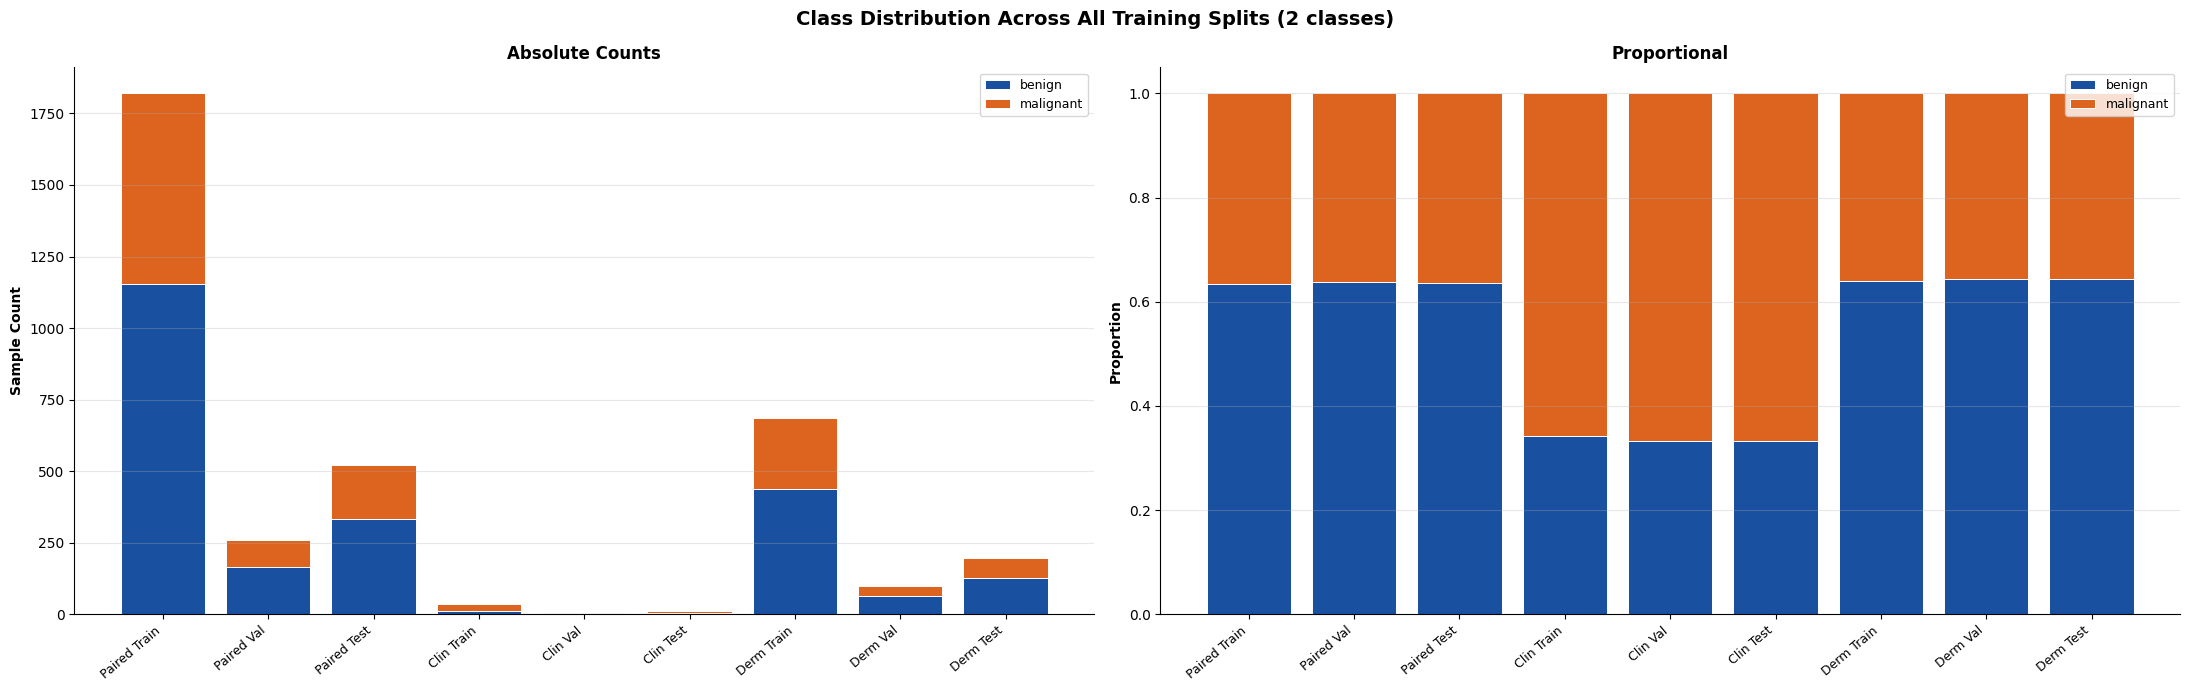

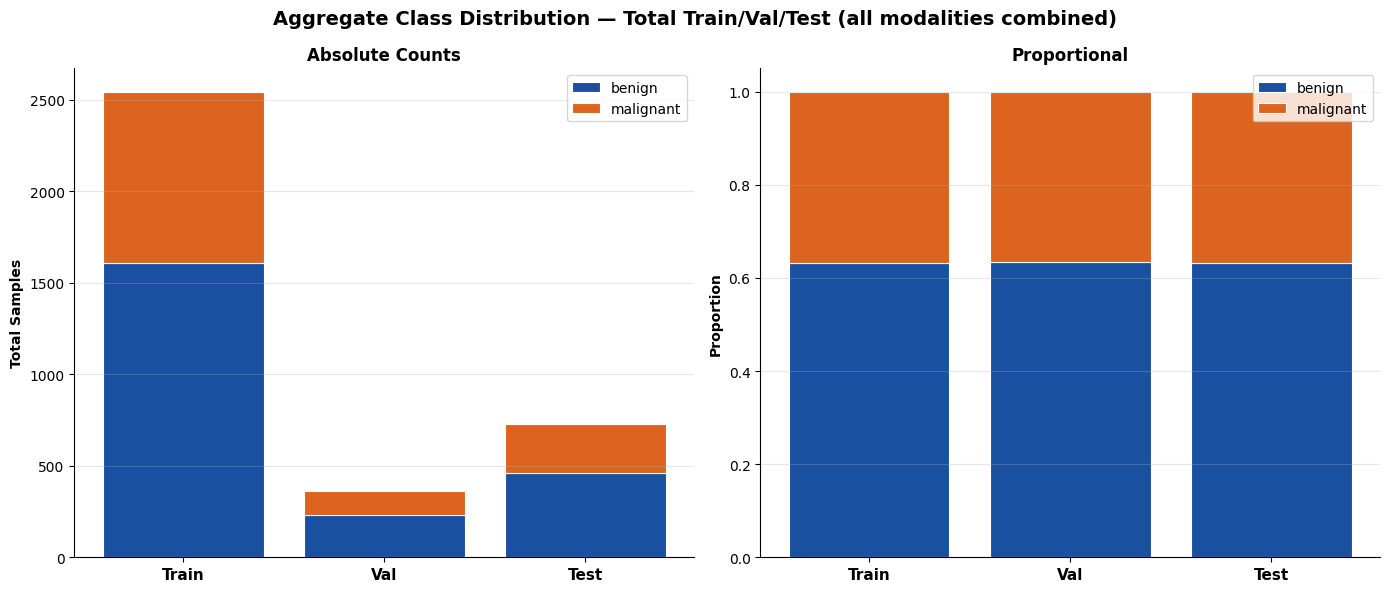

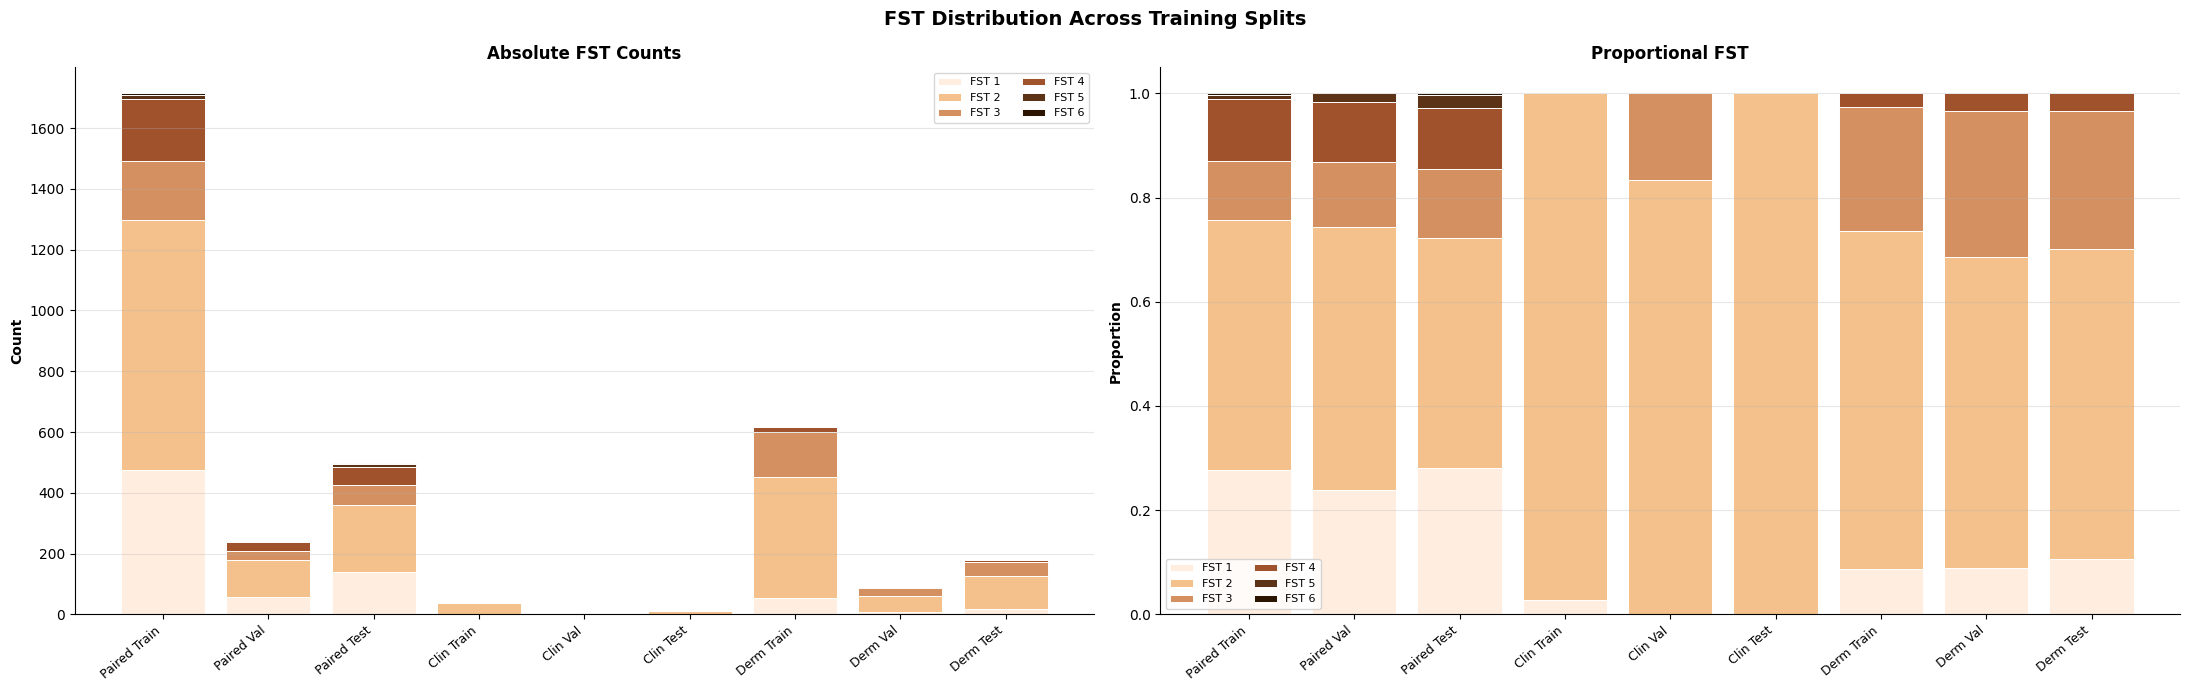

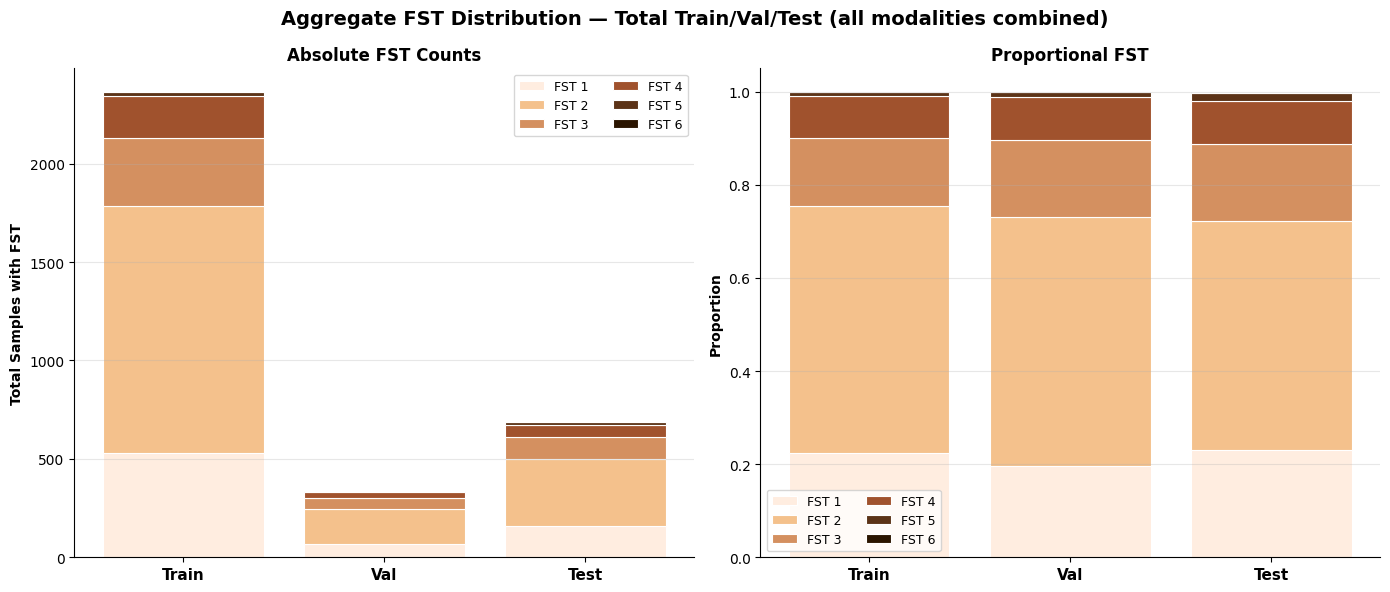

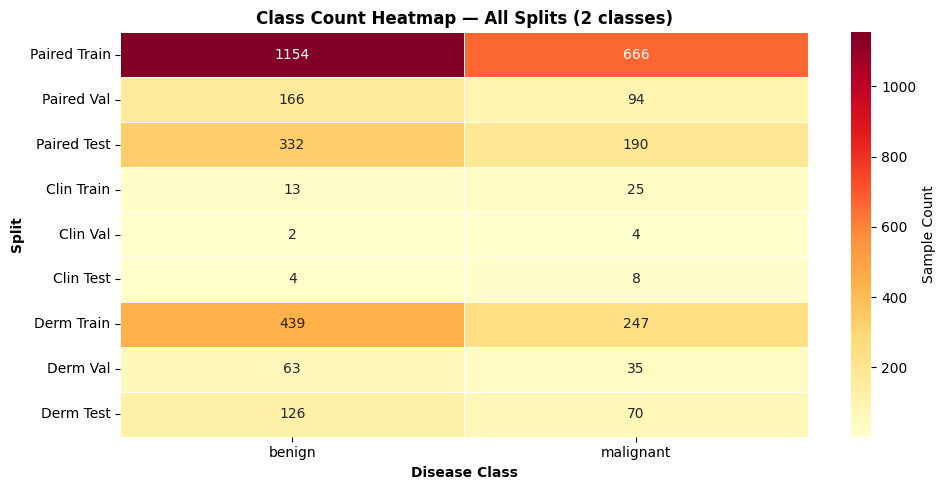

Training EDA saved.


In [127]:
# ════════════════════════════════════════════════════════════════════════════
# EDA — TRAINING SET CLASS & FST DISTRIBUTIONS
# ════════════════════════════════════════════════════════════════════════════
csv_dir = CFG['csv_dir']
_LN  = LABEL_NAMES
_LBL = [_LN[i] for i in range(2)]

def _load(fname):
    p = csv_dir / fname
    return pd.read_csv(p) if p.exists() else pd.DataFrame()

# Load training splits
_tr_splits = {
    'Paired Train':       _load('paired_train.csv'),
    'Paired Val':         _load('paired_val.csv'),
    'Paired Test':        _load('paired_test.csv'),
    'Clin Train':         _load('clin_train.csv'),
    'Clin Val':           _load('clin_val.csv'),
    'Clin Test':          _load('clin_test.csv'),
    'Derm Train':         _load('derm_train.csv'),
    'Derm Val':           _load('derm_val.csv'),
    'Derm Test':          _load('derm_test.csv'),
}
_tr_splits = {k: v for k, v in _tr_splits.items() if not v.empty}

# Define multipliers: paired rows count as 2 samples, unpaired as 1
_multiplier = {name: 2 if 'Paired' in name else 1 for name in _tr_splits}

# ── FIG 1: Stacked class distribution across all splits ───────────────────
if _tr_splits:
    _snames = list(_tr_splits.keys())
    fig, axes = plt.subplots(1, 2, figsize=(22, 7))
    fig.suptitle('Class Distribution Across All Training Splits (2 classes)',
                 fontsize=14, fontweight='bold')
    x = np.arange(len(_snames))
    bot_abs = np.zeros(len(_snames)); bot_prop = np.zeros(len(_snames))
    # totals = number of images = rows * multiplier
    totals = np.array([len(_tr_splits[s]) * _multiplier[s] for s in _snames], dtype=float)
    for ci, lbl in enumerate(_LBL):
        # count rows with this label, then multiply by multiplier
        vals = np.array([_tr_splits[s]['label'].value_counts().get(ci, 0) * _multiplier[s] for s in _snames])
        axes[0].bar(x, vals, bottom=bot_abs,  color=_PAL_CLS[ci], label=lbl,
                    edgecolor='white', lw=0.7)
        axes[1].bar(x, vals/np.maximum(totals, 1), bottom=bot_prop, color=_PAL_CLS[ci],
                    label=lbl, edgecolor='white', lw=0.7)
        bot_abs  += vals
        bot_prop += vals/np.maximum(totals, 1)
    for ax, title, ylabel in [
        (axes[0], 'Absolute Counts', 'Sample Count'),
        (axes[1], 'Proportional',    'Proportion'),
    ]:
        ax.set_xticks(x); ax.set_xticklabels(_snames, rotation=40, ha='right', fontsize=9)
        ax.set_title(title, fontweight='bold'); ax.set_ylabel(ylabel, fontweight='bold')
        ax.legend(fontsize=9); ax.grid(axis='y', alpha=0.3)
        ax.spines[['top','right']].set_visible(False)
    axes[1].set_ylim(0, 1.05)
    plt.tight_layout()
    plt.savefig(CFG['eda_dir']/'eda_class_all_splits.png', dpi=150, bbox_inches='tight')
    plt.show()

# ── FIG 1B: AGGREGATE class distribution (Train/Val/Test totals) ──────────
# Combine Paired+Clin+Derm for each split, with paired weighted by 2
_agg_splits = {}
for split_name in ['Train', 'Val', 'Test']:
    parts = []
    for prefix in ['Paired', 'Clin', 'Derm']:
        key = f'{prefix} {split_name}'
        if key in _tr_splits and not _tr_splits[key].empty:
            df = _tr_splits[key]
            mult = _multiplier[key]
            # Replicate each row 'mult' times to simulate weighted counts
            if mult == 2:
                df_weighted = pd.concat([df, df], ignore_index=True)
            else:
                df_weighted = df
            parts.append(df_weighted)
    if parts:
        _agg_splits[split_name] = pd.concat(parts, ignore_index=True)

if _agg_splits:
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    fig.suptitle('Aggregate Class Distribution — Total Train/Val/Test (all modalities combined)',
                 fontsize=14, fontweight='bold')
    _agg_names = list(_agg_splits.keys())
    x = np.arange(len(_agg_names))
    bot_abs = np.zeros(len(_agg_names)); bot_prop = np.zeros(len(_agg_names))
    totals = np.array([len(_agg_splits[s]) for s in _agg_names], dtype=float)
    
    for ci, lbl in enumerate(_LBL):
        vals = np.array([_agg_splits[s]['label'].value_counts().get(ci, 0) for s in _agg_names])
        axes[0].bar(x, vals, bottom=bot_abs, color=_PAL_CLS[ci], label=lbl,
                    edgecolor='white', lw=0.8)
        axes[1].bar(x, vals/np.maximum(totals, 1), bottom=bot_prop, color=_PAL_CLS[ci],
                    label=lbl, edgecolor='white', lw=0.8)
        bot_abs += vals
        bot_prop += vals/np.maximum(totals, 1)
    
    for ax, title, ylabel in [
        (axes[0], 'Absolute Counts', 'Total Samples'),
        (axes[1], 'Proportional',    'Proportion'),
    ]:
        ax.set_xticks(x); ax.set_xticklabels(_agg_names, fontsize=11, fontweight='bold')
        ax.set_title(title, fontweight='bold', fontsize=12)
        ax.set_ylabel(ylabel, fontweight='bold')
        ax.legend(fontsize=10)
        ax.grid(axis='y', alpha=0.3)
        ax.spines[['top', 'right']].set_visible(False)
    
    axes[1].set_ylim(0, 1.05)
    plt.tight_layout()
    plt.savefig(CFG['eda_dir']/'eda_class_aggregate_splits.png', dpi=150, bbox_inches='tight')
    plt.show()

# ── FIG 2: FST distribution across splits with FST data ───────────────────
_fst_splits = {s: d for s, d in _tr_splits.items()
               if 'skin_type' in d.columns and (d['skin_type'] >= 0).any()}
if _fst_splits:
    _fs = list(_fst_splits.keys())
    fig, axes = plt.subplots(1, 2, figsize=(22, 7))
    fig.suptitle('FST Distribution Across Training Splits', fontsize=14, fontweight='bold')
    x = np.arange(len(_fs)); bot_abs = np.zeros(len(_fs)); bot_prop = np.zeros(len(_fs))
    for fi in range(6):
        # Count FST rows, multiply by multiplier
        vals  = np.array([(d['skin_type']==fi).sum() * _multiplier[name] for name, d in _fst_splits.items()])
        known = np.array([(d['skin_type']>=0).sum() * _multiplier[name] for name, d in _fst_splits.items()], dtype=float)
        axes[0].bar(x, vals, bottom=bot_abs, color=_PAL_FST[fi], label=f'FST {fi+1}',
                    edgecolor='white', lw=0.7)
        axes[1].bar(x, vals/np.maximum(known,1), bottom=bot_prop, color=_PAL_FST[fi],
                    label=f'FST {fi+1}', edgecolor='white', lw=0.7)
        bot_abs  += vals
        bot_prop += vals/np.maximum(known,1)
    for ax, title, ylabel in [
        (axes[0], 'Absolute FST Counts', 'Count'),
        (axes[1], 'Proportional FST',    'Proportion'),
    ]:
        ax.set_xticks(x); ax.set_xticklabels(_fs, rotation=40, ha='right', fontsize=9)
        ax.set_title(title, fontweight='bold'); ax.set_ylabel(ylabel, fontweight='bold')
        ax.legend(fontsize=8, ncol=2); ax.grid(axis='y', alpha=0.3)
        ax.spines[['top','right']].set_visible(False)
    axes[1].set_ylim(0, 1.05)
    plt.tight_layout()
    plt.savefig(CFG['eda_dir']/'eda_fst_all_splits.png', dpi=150, bbox_inches='tight')
    plt.show()

# ── FIG 2B: AGGREGATE FST distribution (Train/Val/Test totals) ────────────
_agg_fst_splits = {}
for split_name in ['Train', 'Val', 'Test']:
    parts = []
    for prefix in ['Paired', 'Clin', 'Derm']:
        key = f'{prefix} {split_name}'
        if key in _tr_splits and not _tr_splits[key].empty:
            d = _tr_splits[key]
            if 'skin_type' in d.columns and (d['skin_type'] >= 0).any():
                mult = _multiplier[key]
                if mult == 2:
                    d_weighted = pd.concat([d, d], ignore_index=True)
                else:
                    d_weighted = d
                parts.append(d_weighted)
    if parts:
        _agg_fst_splits[split_name] = pd.concat(parts, ignore_index=True)

if _agg_fst_splits:
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    fig.suptitle('Aggregate FST Distribution — Total Train/Val/Test (all modalities combined)',
                 fontsize=14, fontweight='bold')
    _agg_fst_names = list(_agg_fst_splits.keys())
    x = np.arange(len(_agg_fst_names))
    bot_abs = np.zeros(len(_agg_fst_names)); bot_prop = np.zeros(len(_agg_fst_names))
    
    for fi in range(6):
        vals  = np.array([(d['skin_type'] == fi).sum() for d in _agg_fst_splits.values()])
        known = np.array([(d['skin_type'] >= 0).sum() for d in _agg_fst_splits.values()], dtype=float)
        axes[0].bar(x, vals, bottom=bot_abs, color=_PAL_FST[fi], label=f'FST {fi+1}',
                    edgecolor='white', lw=0.8)
        axes[1].bar(x, vals/np.maximum(known, 1), bottom=bot_prop, color=_PAL_FST[fi],
                    label=f'FST {fi+1}', edgecolor='white', lw=0.8)
        bot_abs += vals
        bot_prop += vals/np.maximum(known, 1)
    
    for ax, title, ylabel in [
        (axes[0], 'Absolute FST Counts', 'Total Samples with FST'),
        (axes[1], 'Proportional FST',    'Proportion'),
    ]:
        ax.set_xticks(x); ax.set_xticklabels(_agg_fst_names, fontsize=11, fontweight='bold')
        ax.set_title(title, fontweight='bold', fontsize=12)
        ax.set_ylabel(ylabel, fontweight='bold')
        ax.legend(fontsize=9, ncol=2)
        ax.grid(axis='y', alpha=0.3)
        ax.spines[['top', 'right']].set_visible(False)
    
    axes[1].set_ylim(0, 1.05)
    plt.tight_layout()
    plt.savefig(CFG['eda_dir']/'eda_fst_aggregate_splits.png', dpi=150, bbox_inches='tight')
    plt.show()

# ── FIG 3: Class imbalance heatmap ────────────────────────────────────────
_hm_keys = ['Paired Train','Paired Val','Paired Test',
            'Clin Train','Clin Val','Clin Test',
            'Derm Train','Derm Val','Derm Test']
_hm_data = {}
for k in _hm_keys:
    d = _tr_splits.get(k)
    if d is not None and not d.empty:
        mult = _multiplier[k]
        _hm_data[k] = [d['label'].value_counts().get(ci, 0) * mult for ci in range(2)]
if _hm_data:
    _hm_df = pd.DataFrame(_hm_data, index=[_LN[i] for i in range(2)]).T
    fig, ax = plt.subplots(figsize=(10, 5))
    sns.heatmap(_hm_df, annot=True, fmt='d', cmap='YlOrRd', linewidths=0.5,
                linecolor='white', ax=ax, cbar_kws={'label': 'Sample Count'})
    ax.set_title('Class Count Heatmap — All Splits (2 classes)',
                 fontweight='bold', fontsize=12)
    ax.set_xlabel('Disease Class', fontweight='bold')
    ax.set_ylabel('Split', fontweight='bold')
    plt.tight_layout()
    plt.savefig(CFG['eda_dir']/'eda_imbalance_heatmap.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Training EDA saved.')

### 4-B  Cross-Evaluation Datasets: Class & FST Distributions

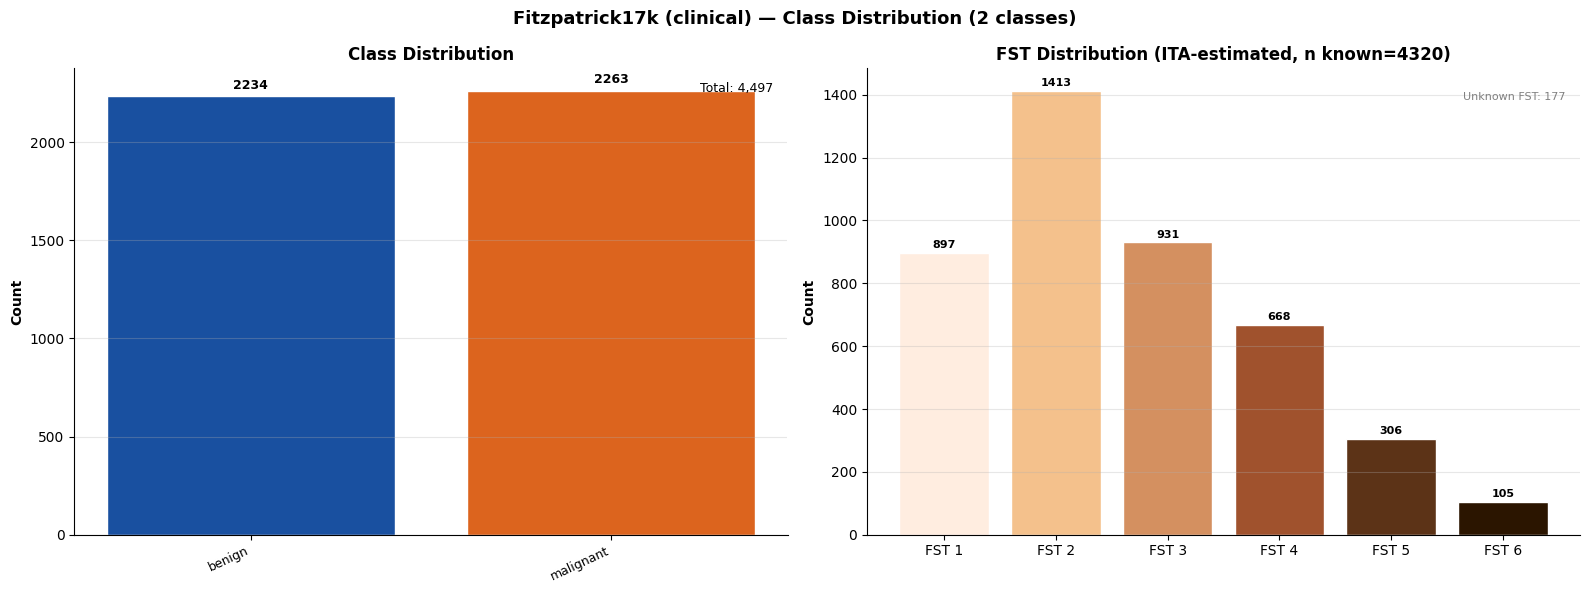

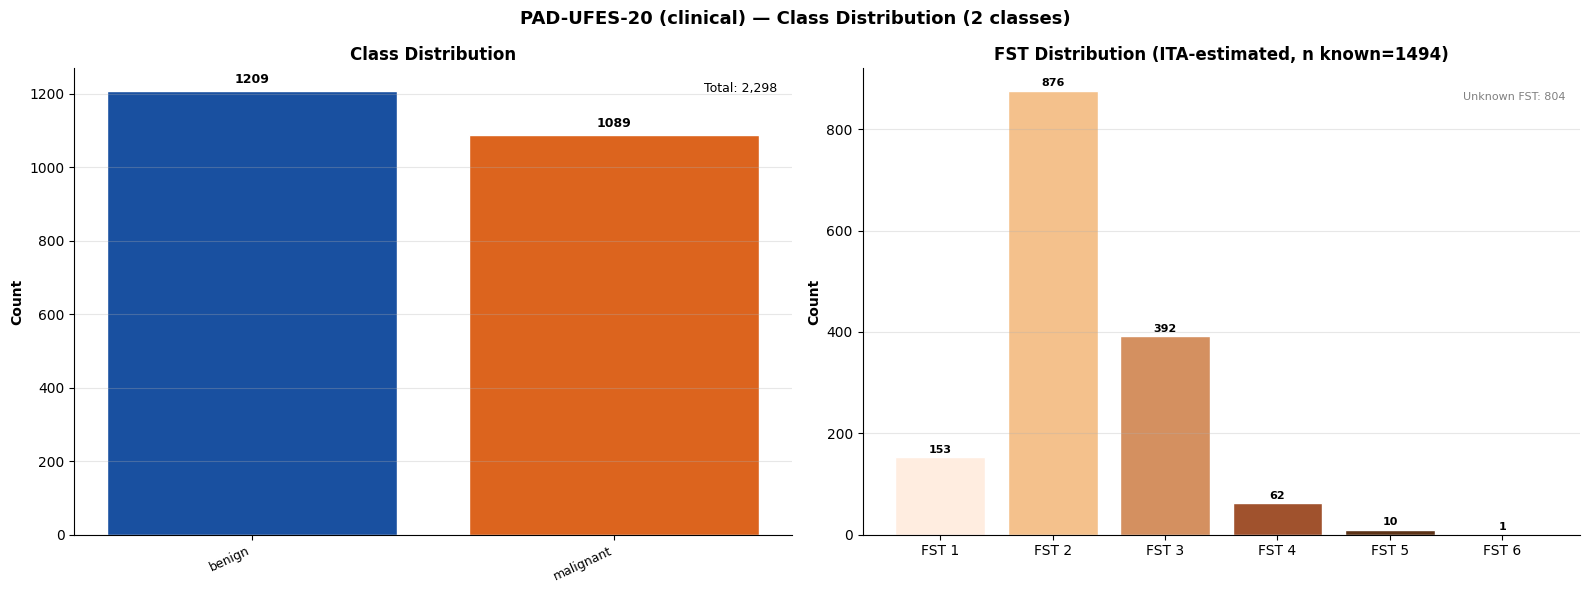

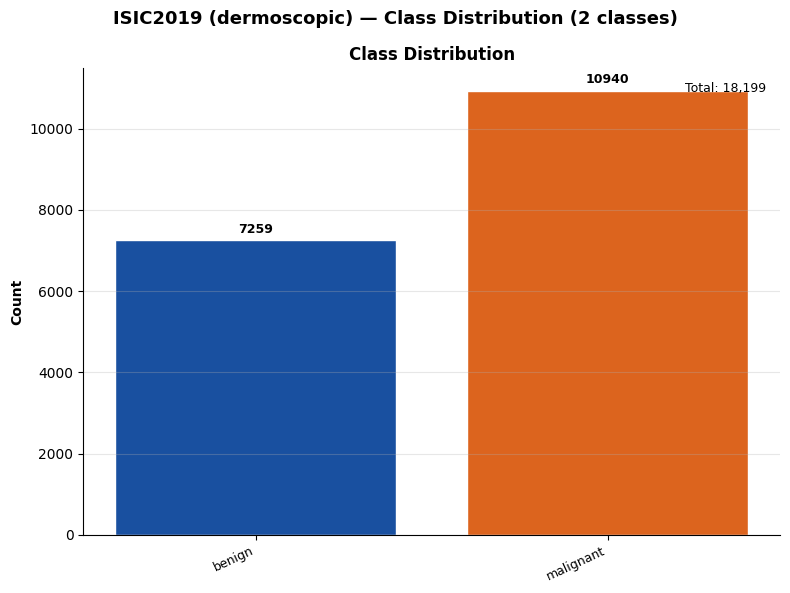

Cross-evaluation EDA saved.


In [128]:
# ════════════════════════════════════════════════════════════════════════════
# EDA — CROSS-EVALUATION DATASET DISTRIBUTIONS
# ════════════════════════════════════════════════════════════════════════════

_eval_sets = {
    'Fitzpatrick17k (clinical)': _load('eval_fitzpatrick17k.csv'),
    'PAD-UFES-20 (clinical)':    _load('eval_padufes20.csv'),
    'ISIC2019 (dermoscopic)':    _load('eval_isic2019.csv'),
}
_eval_sets = {k: v for k, v in _eval_sets.items() if not v.empty}

for ds_name, df_ev in _eval_sets.items():
    has_fst = 'skin_type' in df_ev.columns and (df_ev['skin_type'] >= 0).any()
    ncols   = 2 if has_fst else 1
    fig, axes = plt.subplots(1, ncols, figsize=(8*ncols, 6))
    if ncols == 1:
        axes = [axes]
    fig.suptitle(f'{ds_name} — Class Distribution (2 classes)',
                 fontsize=13, fontweight='bold')

    # Class distribution
    vc = df_ev['label'].value_counts().sort_index()
    bar_cols = [_PAL_CLS[i] for i in vc.index]
    bars = axes[0].bar([_LN.get(i,f'C{i}') for i in vc.index],
                       vc.values, color=bar_cols, edgecolor='white', lw=1)
    for b, n in zip(bars, vc.values):
        axes[0].text(b.get_x()+b.get_width()/2, n+vc.values.max()*0.01,
                     str(n), ha='center', va='bottom', fontsize=9, fontweight='bold')
    axes[0].set_title('Class Distribution', fontweight='bold')
    axes[0].set_xticklabels([_LN.get(i,f'C{i}') for i in vc.index],
                             rotation=25, ha='right', fontsize=9)
    axes[0].set_ylabel('Count', fontweight='bold')
    axes[0].text(0.98, 0.97, f'Total: {len(df_ev):,}',
                 transform=axes[0].transAxes, ha='right', va='top', fontsize=9)
    axes[0].grid(axis='y', alpha=0.3); axes[0].spines[['top','right']].set_visible(False)

    # FST distribution (if available)
    if has_fst:
        fst_ns = [(df_ev['skin_type']==fi).sum() for fi in range(6)]
        n_unk  = int((df_ev['skin_type'] < 0).sum())
        n_kn   = int((df_ev['skin_type'] >= 0).sum())
        fst_src = 'ground-truth' if 'padufes' in ds_name.lower() else 'ITA-estimated'
        b2 = axes[1].bar([f'FST {fi+1}' for fi in range(6)], fst_ns,
                         color=_PAL_FST, edgecolor='white', lw=1)
        for bar, n in zip(b2, fst_ns):
            if n:
                axes[1].text(bar.get_x()+bar.get_width()/2, n+max(fst_ns)*0.01,
                             str(n), ha='center', fontsize=8, fontweight='bold')
        axes[1].set_title(f'FST Distribution ({fst_src}, n known={n_kn})',
                          fontweight='bold')
        axes[1].set_ylabel('Count', fontweight='bold')
        axes[1].text(0.98, 0.95, f'Unknown FST: {n_unk}',
                     transform=axes[1].transAxes, ha='right', va='top',
                     fontsize=8, color='grey')
        axes[1].grid(axis='y', alpha=0.3)
        axes[1].spines[['top','right']].set_visible(False)

    plt.tight_layout()
    safe_name = ds_name.split(' ')[0].lower()
    plt.savefig(CFG['eda_dir']/f'eda_{safe_name}.png', dpi=150, bbox_inches='tight')
    plt.show()

print('Cross-evaluation EDA saved.')


### 4-C  Clinical / Dermoscopy Image Pairs per Class

Building image maps for pair visualisation …


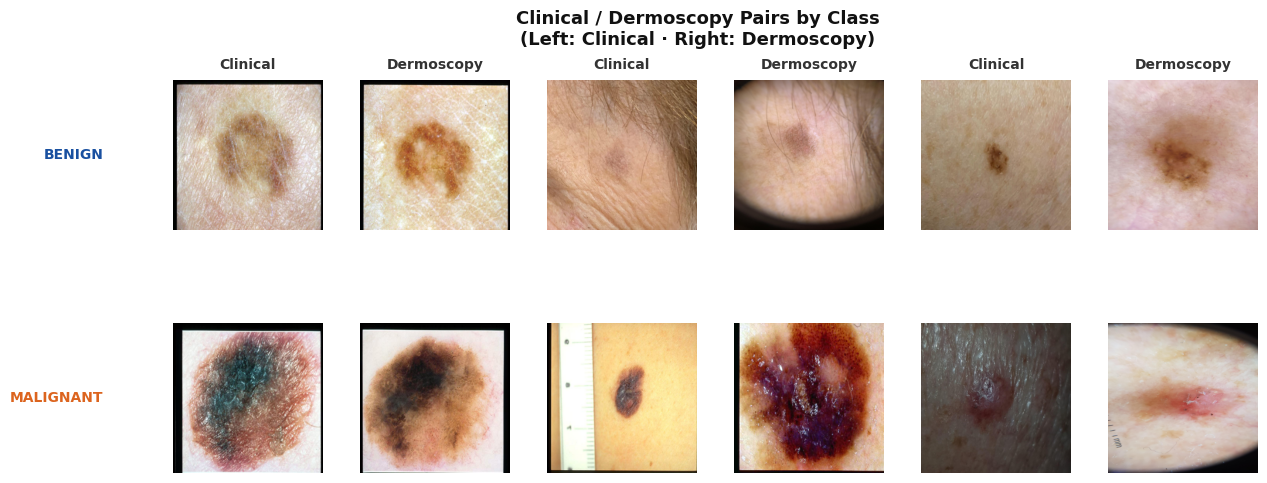

Pair visualization saved → eda_pairs_by_class.png


In [129]:
def _resolve_image_path(stem: str, image_maps: list) -> str | None:
    for im in image_maps:
        p = im.get(stem)
        if p:
            return str(p)
    return None

# Build image maps
print('Building image maps for pair visualisation …')
_hiba_img_map    = _build_image_map(CFG['hiba_root'])
_derm7pt_img_map = _build_image_map(CFG['derm7pt_root'])
_all_maps        = [_hiba_img_map, _derm7pt_img_map]

_paired_df = _load('paired_train.csv')

if _paired_df.empty:
    print('[SKIP] paired_train.csv is empty — skipping pair visualisation.')
else:
    N_PAIRS_PER_CLASS = 3
    CLASSES = list(range(CFG['num_classes']))  # e.g. [0, 1] for Benign / Malignant

    # Figure size: wider to comfortably fit 6 images
    fig = plt.figure(figsize=(14, 5.5))
    fig.suptitle('Clinical / Dermoscopy Pairs by Class\n'
                 '(Left: Clinical · Right: Dermoscopy)',
                 fontsize=13, fontweight='bold', y=0.98, color='#111111')

    # 6 columns: Pair0 (col0,1), Pair1 (col2,3), Pair2 (col4,5)
    cols = N_PAIRS_PER_CLASS * 2
    gs = gridspec.GridSpec(len(CLASSES), cols, wspace=0.25, hspace=0.35)

    for ci, cls_idx in enumerate(CLASSES):
        cls_name = LABEL_NAMES[cls_idx]
        subset = _paired_df[_paired_df['label'] == cls_idx].copy()
        
        # ---------- FST IV‑VI FILTER (explained below) ----------
        # if 'fitzpatrick' in subset.columns:
        #     subset = subset[subset['fitzpatrick'].isin([4, 5, 6])]
        # ---------------------------------------------------------
        
        subset = subset.sample(min(N_PAIRS_PER_CLASS, len(subset)),
                               random_state=SEED).reset_index(drop=True)

        first_ax = None
        for pair_idx in range(N_PAIRS_PER_CLASS):
            c_col = pair_idx * 2          # 0, 2, 4
            d_col = pair_idx * 2 + 1      # 1, 3, 5   <-- FIXED

            ax_c = fig.add_subplot(gs[ci, c_col])
            ax_d = fig.add_subplot(gs[ci, d_col])

            if pair_idx == 0:
                first_ax = ax_c

            # Styling
            for ax in (ax_c, ax_d):
                ax.set_xticks([])
                ax.set_yticks([])
                for spine in ax.spines.values():
                    spine.set_visible(False)

            if pair_idx < len(subset):
                row = subset.iloc[pair_idx]
                clin_path = _resolve_image_path(str(row.get('clinical', '')), _all_maps)
                derm_path = _resolve_image_path(str(row.get('derm', '')),     _all_maps)

                for ax, path, modality in [(ax_c, clin_path, 'Clinical'),
                                           (ax_d, derm_path, 'Dermoscopy')]:
                    if path and Path(path).exists():
                        try:
                            img = Image.open(path).convert('RGB')
                            img = img.resize((256, 256))
                            ax.imshow(img)
                        except Exception:
                            ax.imshow(np.ones((256, 256, 3)) * 0.9)
                            ax.text(128, 128, 'Load Error', ha='center', va='center',
                                    fontsize=9, color='#666666', fontweight='bold')
                    else:
                        ax.imshow(np.ones((256, 256, 3)) * 0.9)
                        ax.text(128, 128, 'Not Found', ha='center', va='center',
                                fontsize=9, color='#666666', fontweight='bold')

                    if ci == 0:
                        ax.set_title(modality, fontsize=10, fontweight='bold', pad=8, color='#333333')
            else:
                # Placeholder for missing pairs
                for ax in (ax_c, ax_d):
                    ax.imshow(np.ones((256, 256, 3)) * 0.95)
                    ax.text(128, 128, 'N/A', ha='center', va='center', fontsize=9, color='#999999')
                    if ci == 0:
                        ax.set_title('N/A', fontsize=10, fontweight='bold', pad=8, color='#999999')

        # Class label on the left
        if first_ax is not None:
            first_ax.set_ylabel(
                cls_name.upper().replace(' ', '\n'),
                rotation=0,
                labelpad=50,      # slightly more space for longer names
                ha='right',
                va='center',
                fontsize=10,
                fontweight='bold',
                color=_PAL_CLS[ci]
            )

    plt.savefig(CFG['eda_dir'] / 'eda_pairs_by_class.png',
                dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Pair visualization saved → eda_pairs_by_class.png')

### 4-D  Coverage Summary

In [130]:
# ════════════════════════════════════════════════════════════════════════════
# COVERAGE SUMMARY — all datasets
# ════════════════════════════════════════════════════════════════════════════

# Define dataset entries: (display_name, filename, modality, fst_source, is_paired)
_all_sources = [
    ('HIBA + Derm7pt (paired train)',  'paired_train.csv',          'paired',   'ground-truth', True),
    ('HIBA + Derm7pt (paired val)',    'paired_val.csv',            'paired',   'ground-truth', True),
    ('HIBA + Derm7pt (paired test)',   'paired_test.csv',           'paired',   'ground-truth', True),
    ('HIBA residual clin (train)',     'clin_train.csv',            'clinical', 'ground-truth', False),
    ('HIBA residual clin (val)',       'clin_val.csv',              'clinical', 'ground-truth', False),
    ('HIBA residual clin (test)',      'clin_test.csv',             'clinical', 'ground-truth', False),
    ('HIBA residual derm (train)',     'derm_train.csv',            'derm',     'ground-truth', False),
    ('HIBA residual derm (val)',       'derm_val.csv',              'derm',     'ground-truth', False),
    ('HIBA residual derm (test)',      'derm_test.csv',             'derm',     'ground-truth', False),
    ('Fitzpatrick17k (cross-eval)',    'eval_fitzpatrick17k.csv',   'clinical', 'ground-truth', False),
    ('PAD-UFES-20 (cross-eval)',       'eval_padufes20.csv',        'clinical', 'ground-truth', False),
    ('ISIC2019 (cross-eval)',          'eval_isic2019.csv',         'derm',     'N/A',          False),
]

cov_rows = []
for tag, fname, modality, fst_src, is_paired in _all_sources:
    d = _load(fname)
    if d.empty: continue
    mult = 2 if is_paired else 1
    n_total = len(d) * mult
    n_fst   = int((d['skin_type'] >= 0).sum() * mult) if 'skin_type' in d.columns else 0
    fst_pct = f'{100*n_fst/max(n_total,1):.0f}%'
    vc      = d['label'].value_counts().sort_index()
    cls_str = '  '.join(f'{LABEL_NAMES.get(k,"?")}={v*mult}' for k, v in vc.items())
    cov_rows.append({'Dataset': tag, 'Modality': modality,
                     'Rows': n_total, 'FST known': n_fst, 'FST%': fst_pct,
                     'FST source': fst_src, 'Class distribution': cls_str})

cov_df = pd.DataFrame(cov_rows).set_index('Dataset')
print()
print('── Coverage Summary (3-class setup) ─────────────────────────────────────')
print(cov_df[['Modality','Rows','FST known','FST%','FST source']].to_string())
print()
print('── Class distribution ───────────────────────────────────────────────────')
print(cov_df[['Class distribution']].to_string())
cov_df.to_csv(CFG['eda_dir']/'eda_coverage_summary.csv')
print()
print('Saved → eda_coverage_summary.csv')
print()

# Paired fraction of training data (images, not rows)
_ptr = _load('paired_train.csv')
_ctr = _load('clin_train.csv')
_dtr = _load('derm_train.csv')
_total_tr = 2*len(_ptr) + len(_ctr) + len(_dtr)
_pct = 100*(2*len(_ptr))/max(_total_tr,1)
print(f'Paired fraction of training data: {_pct:.1f}%  '
      f'({2*len(_ptr)} paired images / {_total_tr} total images)')


── Coverage Summary (3-class setup) ─────────────────────────────────────
                               Modality   Rows  FST known  FST%    FST source
Dataset                                                                      
HIBA + Derm7pt (paired train)    paired   1820       1714   94%  ground-truth
HIBA + Derm7pt (paired val)      paired    260        242   93%  ground-truth
HIBA + Derm7pt (paired test)     paired    522        498   95%  ground-truth
HIBA residual clin (train)     clinical     38         37   97%  ground-truth
HIBA residual clin (val)       clinical      6          6  100%  ground-truth
HIBA residual clin (test)      clinical     12         12  100%  ground-truth
HIBA residual derm (train)         derm    686        615   90%  ground-truth
HIBA residual derm (val)           derm     98         89   91%  ground-truth
HIBA residual derm (test)          derm    196        178   91%  ground-truth
Fitzpatrick17k (cross-eval)    clinical   4497       4320   96%  gr

Creating raw source distribution visualizations …
[HIBA] 1616 rows loaded
[HIBA] FST column: fitzpatrick_skin_type
[HIBA] image map: 3232 entries
[HIBA paired] classes: benign=109  malignant=181
[HIBA] paired=290  unpaired_clin=56  unpaired_derm=980
[Derm7pt] 1011 rows loaded
[Derm7pt] image map: 4026 entries
[Derm7pt] 1011 rows kept | 0 skipped (outside 3 classes)
[Derm7pt] classes: benign=717  malignant=294
  [FST cache] loaded 946/1011 from derm7pt_train_fst_cache.csv


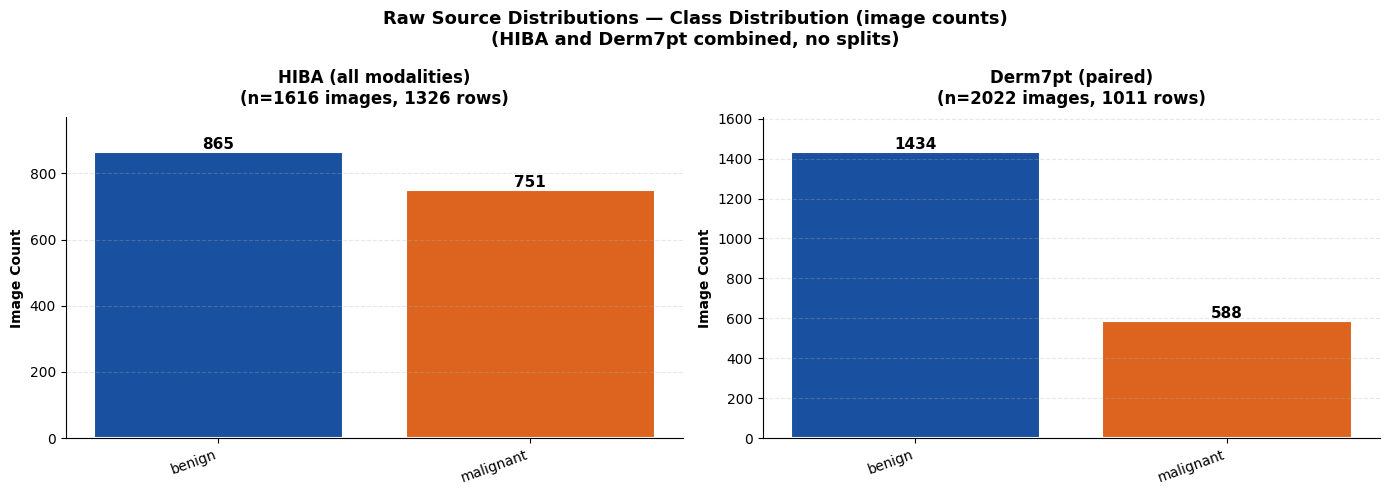

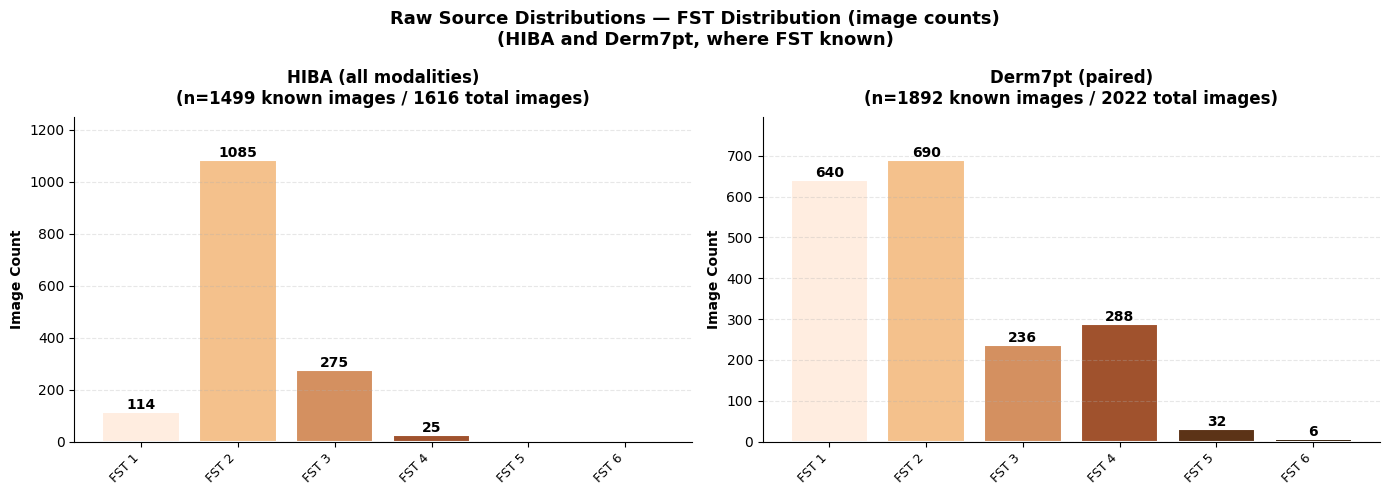

Raw source distributions saved.


In [131]:
# ════════════════════════════════════════════════════════════════════════════
# RAW SOURCE DISTRIBUTIONS — HIBA vs Derm7pt (before splitting)
# ════════════════════════════════════════════════════════════════════════════

print('Creating raw source distribution visualizations …')

# Reload raw source data (before any splitting)
hiba_paired_raw, hiba_uclin_raw, hiba_uderm_raw = parse_hiba_2cls(CFG['hiba_root'])
derm7pt_paired_raw = parse_derm7pt_train(CFG['derm7pt_root'])

# Prepare HIBA data with source indicators
hiba_parts = []
if not hiba_paired_raw.empty:
    tmp = hiba_paired_raw.copy()
    tmp['_source'] = 'paired'
    tmp['_weight'] = 2  # each row = clinical + dermoscopy image
    hiba_parts.append(tmp)
if not hiba_uclin_raw.empty:
    tmp = hiba_uclin_raw.copy()
    tmp['_source'] = 'unpaired_clin'
    tmp['_weight'] = 1
    hiba_parts.append(tmp)
if not hiba_uderm_raw.empty:
    tmp = hiba_uderm_raw.copy()
    tmp['_source'] = 'unpaired_derm'
    tmp['_weight'] = 1
    hiba_parts.append(tmp)

hiba_all = pd.concat(hiba_parts, ignore_index=True) if hiba_parts else pd.DataFrame()

# Derm7pt is fully paired, so each row counts as 2 images
derm7pt_all = derm7pt_paired_raw.copy()
derm7pt_all['_weight'] = 2

# ── CLASS DISTRIBUTION ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Raw Source Distributions — Class Distribution (image counts)\n(HIBA and Derm7pt combined, no splits)',
             fontsize=13, fontweight='bold', y=0.98)

# Helper to compute weighted counts
def weighted_class_counts(df):
    if df.empty or 'label' not in df.columns:
        return pd.Series()
    # group by label and sum weights
    return df.groupby('label')['_weight'].sum()

for ax, data, label in [
    (axes[0], hiba_all, 'HIBA (all modalities)'),
    (axes[1], derm7pt_all, 'Derm7pt (paired)'),
]:
    if data.empty:
        ax.text(0.5, 0.5, f'{label} is empty', ha='center', va='center',
                transform=ax.transAxes, fontsize=11, color='red')
        ax.set_xticks([])
        ax.set_yticks([])
        continue
    
    vc = weighted_class_counts(data)
    if vc.empty:
        ax.text(0.5, 0.5, f'{label}\nNo class data', ha='center', va='center',
                transform=ax.transAxes, fontsize=11, color='gray')
        ax.set_xticks([])
        ax.set_yticks([])
        continue
    
    class_names = [LABEL_NAMES.get(i, f'Class {i}') for i in vc.index]
    counts = vc.values.astype(int)  # weights are integers
    colors = [_PAL_CLS[i] for i in vc.index]
    
    bars = ax.bar(class_names, counts, color=colors, edgecolor='white', linewidth=1.5)
    
    for bar, count in zip(bars, counts):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{int(count)}',
                ha='center', va='bottom', fontsize=11, fontweight='bold')
    
    total_images = int(data['_weight'].sum())
    ax.set_title(f'{label}\n(n={total_images} images, {len(data)} rows)',
                 fontsize=12, fontweight='bold', pad=10)
    ax.set_ylabel('Image Count', fontweight='bold', fontsize=10)
    ax.set_xticklabels(class_names, rotation=20, ha='right', fontsize=10)
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    ax.spines[['top', 'right']].set_visible(False)
    
    max_count = counts.max() if len(counts) > 0 else 100
    ax.set_ylim(0, max_count * 1.12)

plt.tight_layout()
plt.savefig(CFG['eda_dir']/'eda_raw_source_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# ── FST DISTRIBUTION ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Raw Source Distributions — FST Distribution (image counts)\n(HIBA and Derm7pt, where FST known)',
             fontsize=13, fontweight='bold', y=0.98)

for ax, data, label in [
    (axes[0], hiba_all, 'HIBA (all modalities)'),
    (axes[1], derm7pt_all, 'Derm7pt (paired)'),
]:
    if data.empty or 'skin_type' not in data.columns or not (data['skin_type'] >= 0).any():
        ax.text(0.5, 0.5, f'{label}\nNo FST data', ha='center', va='center',
                transform=ax.transAxes, fontsize=11, color='gray')
        ax.set_xticks([])
        ax.set_yticks([])
        continue
    
    # Weighted FST counts
    fst_counts = []
    for fi in range(6):
        subset = data[data['skin_type'] == fi]
        fst_counts.append(int(subset['_weight'].sum()))
    
    fst_labels = [f'FST {fi+1}' for fi in range(6)]
    n_known = int(data[data['skin_type'] >= 0]['_weight'].sum())
    n_total = int(data['_weight'].sum())
    
    bars = ax.bar(fst_labels, fst_counts, color=_PAL_FST, edgecolor='white', linewidth=1.5)
    
    for bar, count in zip(bars, fst_counts):
        if count > 0:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height,
                    f'{int(count)}',
                    ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    ax.set_title(f'{label}\n(n={n_known} known images / {n_total} total images)',
                 fontsize=12, fontweight='bold', pad=10)
    ax.set_ylabel('Image Count', fontweight='bold', fontsize=10)
    ax.set_xticklabels(fst_labels, rotation=45, ha='right', fontsize=9)
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    ax.spines[['top', 'right']].set_visible(False)
    
    max_count = max(fst_counts) if fst_counts else 100
    ax.set_ylim(0, max_count * 1.15)

plt.tight_layout()
plt.savefig(CFG['eda_dir']/'eda_raw_source_fst_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print('Raw source distributions saved.')

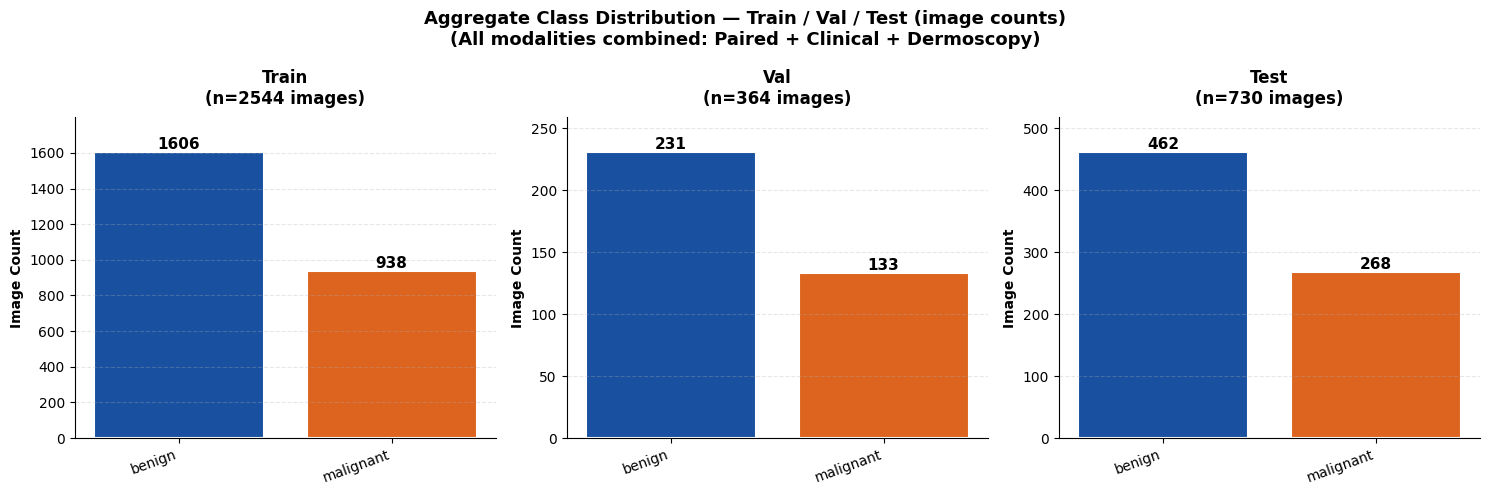

Aggregate class distribution plot saved → eda_aggregate_class_train_val_test.png


In [132]:
# ════════════════════════════════════════════════════════════════════════════
# AGGREGATE CLASS DISTRIBUTION — Train/Val/Test with counts on bars (image counts)
# ════════════════════════════════════════════════════════════════════════════

def load_weighted(fname, weight=1):
    """Load a CSV and replicate rows if weight > 1 to represent multiple images."""
    df = _load(fname)
    if df.empty:
        return df
    if weight == 2:
        # Duplicate rows to count as two images (clinical + dermoscopy)
        return pd.concat([df, df], ignore_index=True)
    return df

# Load and aggregate each split (Paired + Clin + Derm combined)
_agg_train_parts = []
_agg_val_parts   = []
_agg_test_parts  = []

# Paired gets weight 2
_agg_train_parts.append(load_weighted('paired_train.csv', 2))
_agg_val_parts.append(load_weighted('paired_val.csv', 2))
_agg_test_parts.append(load_weighted('paired_test.csv', 2))

# Clinical and dermoscopy get weight 1
_agg_train_parts.append(load_weighted('clin_train.csv', 1))
_agg_val_parts.append(load_weighted('clin_val.csv', 1))
_agg_test_parts.append(load_weighted('clin_test.csv', 1))

_agg_train_parts.append(load_weighted('derm_train.csv', 1))
_agg_val_parts.append(load_weighted('derm_val.csv', 1))
_agg_test_parts.append(load_weighted('derm_test.csv', 1))

_agg_train = pd.concat([d for d in _agg_train_parts if not d.empty], ignore_index=True)
_agg_val   = pd.concat([d for d in _agg_val_parts if not d.empty], ignore_index=True)
_agg_test  = pd.concat([d for d in _agg_test_parts if not d.empty], ignore_index=True)

# Create figure with 3 subplots (one per split)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Aggregate Class Distribution — Train / Val / Test (image counts)\n(All modalities combined: Paired + Clinical + Dermoscopy)',
             fontsize=13, fontweight='bold', y=0.98)

splits = [
    (_agg_train, 'Train', axes[0]),
    (_agg_val, 'Val', axes[1]),
    (_agg_test, 'Test', axes[2]),
]

for df_split, split_name, ax in splits:
    if df_split.empty:
        ax.text(0.5, 0.5, f'{split_name} set is empty', ha='center', va='center',
                transform=ax.transAxes, fontsize=11, color='red')
        ax.set_xticks([]); ax.set_yticks([])
        continue
    
    # Get class counts
    vc = df_split['label'].value_counts().sort_index()
    class_labels = [LABEL_NAMES.get(i, f'Class {i}') for i in vc.index]
    counts = vc.values
    colors = [_PAL_CLS[i] for i in vc.index]
    
    # Create bars
    bars = ax.bar(class_labels, counts, color=colors, edgecolor='white', linewidth=1.5)
    
    # Add count labels on top of each bar
    for bar, count in zip(bars, counts):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{int(count)}',
                ha='center', va='bottom', fontsize=11, fontweight='bold')
    
    # Styling
    ax.set_title(f'{split_name}\n(n={len(df_split)} images)', fontsize=12, fontweight='bold', pad=10)
    ax.set_ylabel('Image Count', fontweight='bold', fontsize=10)
    ax.set_xticklabels(class_labels, rotation=20, ha='right', fontsize=10)
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    ax.spines[['top', 'right']].set_visible(False)
    
    # Set y-axis to allow space for labels
    max_count = counts.max() if len(counts) > 0 else 100
    ax.set_ylim(0, max_count * 1.12)

plt.tight_layout()
plt.savefig(CFG['eda_dir']/'eda_aggregate_class_train_val_test.png', dpi=150, bbox_inches='tight')
plt.show()

print('Aggregate class distribution plot saved → eda_aggregate_class_train_val_test.png')

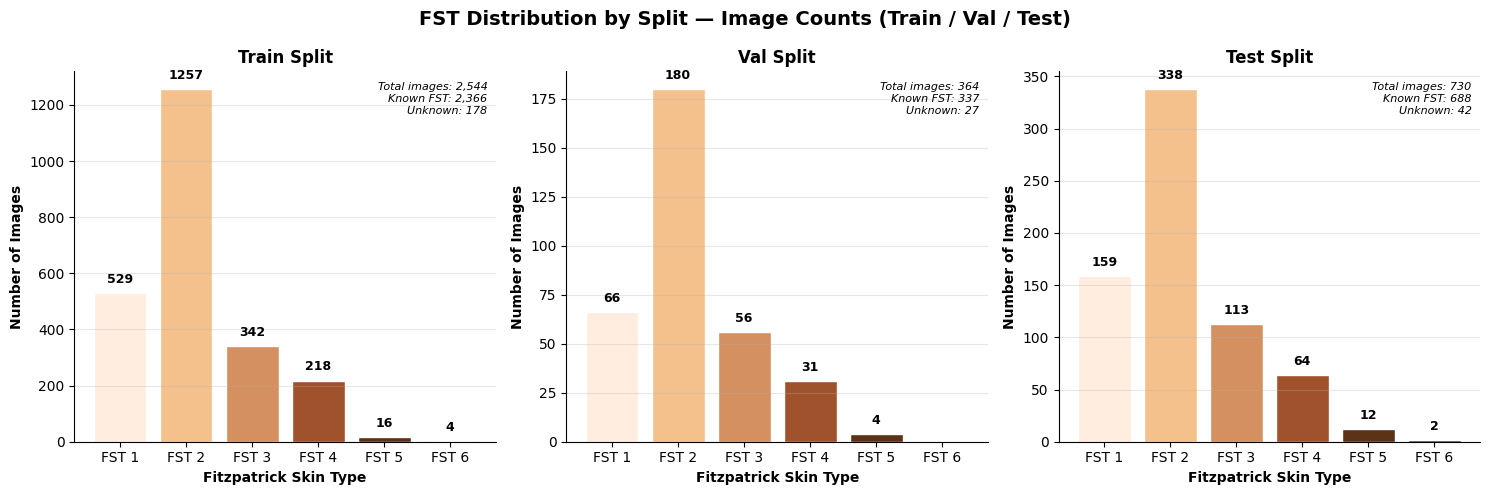

In [133]:
# ════════════════════════════════════════════════════════════════════════════
# AGGREGATE FST DISTRIBUTION PER SPLIT — Separate bar charts for Train/Val/Test (image counts)
# ════════════════════════════════════════════════════════════════════════════

# Function to load and weight a split CSV for FST analysis
def load_weighted_fst(fname, weight=1):
    df = _load(fname)
    if df.empty:
        return df
    if weight == 2:
        # Duplicate rows to count as two images (clinical + dermoscopy)
        return pd.concat([df, df], ignore_index=True)
    return df

# Build weighted FST splits for Train, Val, Test
_agg_fst_splits_weighted = {}

for split_name in ['Train', 'Val', 'Test']:
    parts = []
    split_lower = split_name.lower()
    
    # Paired gets weight 2 (clinical + dermoscopy)
    paired_df = load_weighted_fst(f'paired_{split_lower}.csv', 2)
    if not paired_df.empty and 'skin_type' in paired_df.columns and (paired_df['skin_type'] >= 0).any():
        parts.append(paired_df)
    
    # Clinical and dermoscopy get weight 1
    clin_df = load_weighted_fst(f'clin_{split_lower}.csv', 1)
    if not clin_df.empty and 'skin_type' in clin_df.columns and (clin_df['skin_type'] >= 0).any():
        parts.append(clin_df)
    
    derm_df = load_weighted_fst(f'derm_{split_lower}.csv', 1)
    if not derm_df.empty and 'skin_type' in derm_df.columns and (derm_df['skin_type'] >= 0).any():
        parts.append(derm_df)
    
    if parts:
        _agg_fst_splits_weighted[split_name] = pd.concat(parts, ignore_index=True)

# Create a figure with three subplots (one per split)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('FST Distribution by Split — Image Counts (Train / Val / Test)',
             fontsize=14, fontweight='bold')

for idx, split_name in enumerate(['Train', 'Val', 'Test']):
    ax = axes[idx]
    df_split = _agg_fst_splits_weighted.get(split_name)
    if df_split is None or df_split.empty:
        ax.text(0.5, 0.5, f'No FST data for {split_name}',
                ha='center', va='center', transform=ax.transAxes)
        ax.set_title(split_name)
        continue

    # Count FST values 0-5 (maps to FST 1-6)
    fst_counts = [(df_split['skin_type'] == fi).sum() for fi in range(6)]
    bars = ax.bar([f'FST {i+1}' for i in range(6)], fst_counts,
                  color=_PAL_FST, edgecolor='white', lw=1)

    # Add count labels on top of bars
    max_count = max(fst_counts) if fst_counts else 1
    for bar, count in zip(bars, fst_counts):
        if count > 0:
            ax.text(bar.get_x() + bar.get_width()/2, count + max_count * 0.02,
                    str(count), ha='center', va='bottom', fontsize=9, fontweight='bold')

    ax.set_title(f'{split_name} Split', fontweight='bold')
    ax.set_ylabel('Number of Images', fontweight='bold')
    ax.set_xlabel('Fitzpatrick Skin Type', fontweight='bold')
    ax.grid(axis='y', alpha=0.3)
    ax.spines[['top', 'right']].set_visible(False)

    # Add annotation with total and unknown counts (image counts)
    known = sum(fst_counts)
    total_images = len(df_split)
    unknown = total_images - known
    ax.text(0.98, 0.97, f'Total images: {total_images:,}\nKnown FST: {known:,}\nUnknown: {unknown:,}',
            transform=ax.transAxes, ha='right', va='top', fontsize=8, style='italic')

plt.tight_layout()
plt.savefig(CFG['eda_dir']/'eda_fst_per_split_bar_charts.png', dpi=150, bbox_inches='tight')
plt.show()

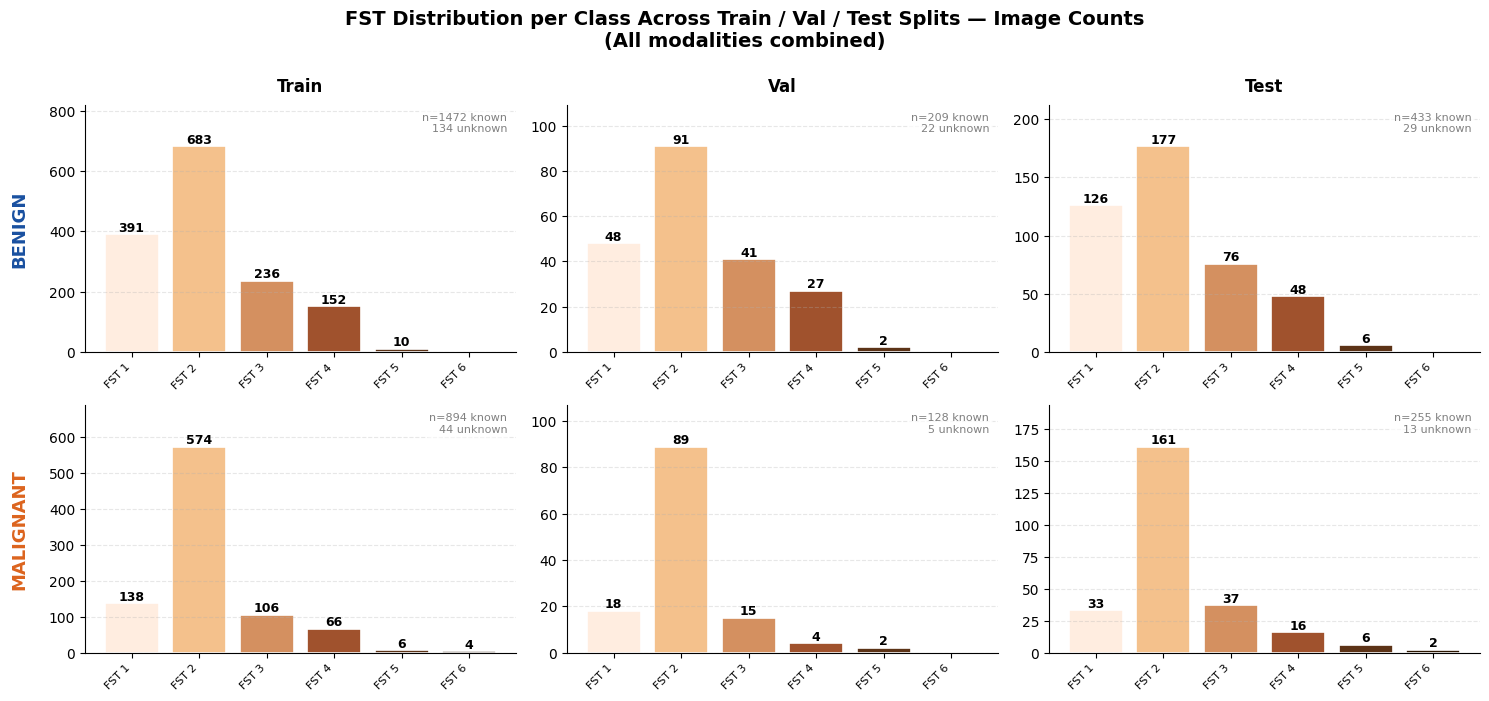

FST per-class distribution plot saved → eda_fst_per_class_train_val_test.png


In [136]:
# ════════════════════════════════════════════════════════════════════════════
# FST DISTRIBUTION PER CLASS — Across Train/Val/Test splits (image counts)
# ════════════════════════════════════════════════════════════════════════════

# Function to load and weight a split CSV for FST analysis (same as before)
def load_weighted_fst(fname, weight=1):
    df = _load(fname)
    if df.empty:
        return df
    if weight == 2:
        return pd.concat([df, df], ignore_index=True)
    return df

# Build weighted splits for Train, Val, Test (full datasets with class & FST)
_agg_train_weighted_parts = []
_agg_val_weighted_parts = []
_agg_test_weighted_parts = []

for prefix in ['paired', 'clin', 'derm']:
    weight = 2 if prefix == 'paired' else 1
    _agg_train_weighted_parts.append(load_weighted_fst(f'{prefix}_train.csv', weight))
    _agg_val_weighted_parts.append(load_weighted_fst(f'{prefix}_val.csv', weight))
    _agg_test_weighted_parts.append(load_weighted_fst(f'{prefix}_test.csv', weight))

_agg_train_weighted = pd.concat([d for d in _agg_train_weighted_parts if not d.empty], ignore_index=True)
_agg_val_weighted   = pd.concat([d for d in _agg_val_weighted_parts if not d.empty], ignore_index=True)
_agg_test_weighted  = pd.concat([d for d in _agg_test_weighted_parts if not d.empty], ignore_index=True)

# Create a figure with 2 rows (one per class) and 3 columns (one per split)
fig, axes = plt.subplots(2, 3, figsize=(15, 7))
fig.suptitle('FST Distribution per Class Across Train / Val / Test Splits — Image Counts\n(All modalities combined)',
             fontsize=14, fontweight='bold', y=0.995)

splits_data = [
    (_agg_train_weighted, 'Train'),
    (_agg_val_weighted, 'Val'),
    (_agg_test_weighted, 'Test'),
]

class_indices = [0, 1]

for row_idx, cls_idx in enumerate(class_indices):
    cls_name = LABEL_NAMES[cls_idx]
    
    for col_idx, (df_split, split_name) in enumerate(splits_data):
        ax = axes[row_idx, col_idx]
        
        if df_split.empty:
            ax.text(0.5, 0.5, f'{split_name} empty', ha='center', va='center',
                    transform=ax.transAxes, fontsize=10, color='red')
            ax.set_xticks([]); ax.set_yticks([])
            continue
        
        # Filter for this class
        df_class = df_split[df_split['label'] == cls_idx]
        
        if df_class.empty:
            ax.text(0.5, 0.5, f'No {cls_name}', ha='center', va='center',
                    transform=ax.transAxes, fontsize=10, color='gray')
            ax.set_xticks([]); ax.set_yticks([])
            continue
        
        # Get FST distribution (only samples with known FST)
        df_class_fst = df_class[df_class['skin_type'] >= 0]
        n_known = len(df_class_fst)  # already image count due to weighting
        n_unknown = len(df_class) - n_known
        
        if n_known == 0:
            ax.text(0.5, 0.5, f'No FST data\n({n_unknown} images)', ha='center', va='center',
                    transform=ax.transAxes, fontsize=9, color='gray')
            ax.set_xticks([]); ax.set_yticks([])
            continue
        
        # Count FST values (0-5)
        fst_counts = [int((df_class_fst['skin_type'] == fi).sum()) for fi in range(6)]
        fst_labels = [f'FST {fi+1}' for fi in range(6)]
        
        # Create bars
        bars = ax.bar(fst_labels, fst_counts, color=_PAL_FST, edgecolor='white', linewidth=1.2)
        
        # Add count labels on top of bars
        for bar, count in zip(bars, fst_counts):
            if count > 0:
                height = bar.get_height()
                ax.text(bar.get_x() + bar.get_width()/2., height,
                        f'{int(count)}',
                        ha='center', va='bottom', fontsize=9, fontweight='bold')
        
        # Title: class name on left, split info on top
        if col_idx == 0:
            ax.set_ylabel(cls_name.replace(' ', '\n').upper(), fontweight='bold', fontsize=13, 
                         color=_PAL_CLS[cls_idx], labelpad=15)
        
        if row_idx == 0:
            ax.set_title(f'{split_name}', fontsize=12, fontweight='bold', pad=10)
        
        # Styling
        ax.set_xticklabels(fst_labels, rotation=45, ha='right', fontsize=8)
        ax.grid(axis='y', alpha=0.3, linestyle='--')
        ax.spines[['top', 'right']].set_visible(False)
        
        # Add info text about FST coverage (image counts)
        ax.text(0.98, 0.97, f'n={n_known} known\n{n_unknown} unknown',
                transform=ax.transAxes, ha='right', va='top', fontsize=8, color='gray',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7, edgecolor='none'))
        
        # Set y-axis limit with some headroom
        if max(fst_counts) > 0:
            ax.set_ylim(0, max(fst_counts) * 1.2)

plt.tight_layout()
plt.savefig(CFG['eda_dir']/'eda_fst_per_class_train_val_test.png', dpi=150, bbox_inches='tight')
plt.show()

print('FST per-class distribution plot saved → eda_fst_per_class_train_val_test.png')